# Mortgage Rate Forecasting & Preprocessing, Leakage Audit, Robust Baseline
**Patrick Lynch | Capstone | DSE 6311**  
**Story from the data:** mixed-frequency FRED series → exogenous features → leakage ablation → locked LightGBM → multi-origin robustness

GitHub: `https://github.com/lynchpo/dragon_exploder_fred`

## 1. Landscape and Research Question

**Question:** Can exogenous macroeconomic series from FRED support accurate forecasts of the 30-year fixed mortgage rate, and where does that signal fail?

**Literature anchors (macro-finance):**
- Interest rates are hard to forecast; random-walk benchmarks are strong (Bauer / FRBSF).
- Macro information is regime-dependent (Bie et al. on yield-curve regimes).
- Structural breaks cause forecast failure (Pinto & Castle).
- 2022: mortgage rates moved more than Treasuries (Frame & McCormick); professionals underpredicted the tightening (ECB).

**This notebook’s job:** build a *leakage-free* pipeline, prove what was and was not leakage, lock a baseline model, and test it at several historical origins.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)

TARGET = 'MORTGAGE30US'

In [2]:
series_urls = {
    'MORTGAGE30US': 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US',
    'DGS10':        'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10',
    'FEDFUNDS':     'https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS',
    'UNRATE':       'https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE',
    'CPIAUCSL':     'https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL',
    'HOUST':        'https://fred.stlouisfed.org/graph/fredgraph.csv?id=HOUST',
}

raw = {}
for name, url in series_urls.items():
    r = requests.get(url, timeout=20)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text), parse_dates=['observation_date'])
    df = df.rename(columns={'observation_date': 'date', name: name}).set_index('date').sort_index()
    raw[name] = df

start = '2000-01-01'
mort  = raw['MORTGAGE30US'].loc[start:].resample('W-FRI').last()
dgs10 = raw['DGS10'].loc[start:].resample('W-FRI').last()
fed   = raw['FEDFUNDS'].loc[start:].resample('W-FRI').last().ffill()
unrate= raw['UNRATE'].loc[start:].resample('W-FRI').last().ffill()
cpi   = raw['CPIAUCSL'].loc[start:].resample('W-FRI').last().ffill()
houst = raw['HOUST'].loc[start:].resample('W-FRI').last().ffill()

df = pd.concat([mort, dgs10, fed, unrate, cpi, houst], axis=1)
df.columns = ['MORTGAGE30US', 'DGS10', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'HOUST']
print('Aligned shape:', df.shape)
print(df.isna().sum())

Aligned shape: (1388, 6)
MORTGAGE30US    0
DGS10           0
FEDFUNDS        5
UNRATE          9
CPIAUCSL        9
HOUST           9
dtype: int64


## 2. Feature Engineering — Exogenous Only

Rules:
- No lags or rolling stats of `MORTGAGE30US` in the predictor set.
- Lags, rolling means/std, rate-of-change, and regime flags only from external series.

In [3]:
feat = df.copy()
feat['YIELD_SPREAD'] = feat['DGS10'] - feat['FEDFUNDS']

external = ['DGS10', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'HOUST', 'YIELD_SPREAD']
for var in external:
    for lag in [1, 2, 4, 8, 12]:
        feat[f'{var}_lag{lag}'] = feat[var].shift(lag)

for var in ['DGS10', 'FEDFUNDS', 'YIELD_SPREAD']:
    feat[f'{var}_roll4_mean']  = feat[var].rolling(4).mean()
    feat[f'{var}_roll4_std']   = feat[var].rolling(4).std()
    feat[f'{var}_roll12_mean'] = feat[var].rolling(12).mean()
    feat[f'{var}_roll12_std']  = feat[var].rolling(12).std()

for var in ['DGS10', 'FEDFUNDS']:
    for w in [1, 2, 4, 8, 12]:
        feat[f'{var}_roc{w}'] = feat[var].pct_change(w)

feat['FEDFUNDS_change_12w'] = feat['FEDFUNDS'] - feat['FEDFUNDS'].shift(12)
feat['tightening_flag'] = (feat['FEDFUNDS_change_12w'] > 0.50).astype(int)
feat['DGS10_vol12'] = feat['DGS10'].rolling(12).std()

feat = feat.dropna()
features = [c for c in feat.columns if c != TARGET]
assert not any(c.startswith('MORTGAGE30US_') for c in features), "Leakage columns present!"
print('Clean shape:', feat.shape)
print('N predictors:', len(features))

Clean shape: (1367, 62)
N predictors: 61


/tmp/ipykernel_3571/2582822801.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  feat[f'{var}_roc{w}'] = feat[var].pct_change(w)
/tmp/ipykernel_3571/2582822801.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  feat[f'{var}_roc{w}'] = feat[var].pct_change(w)
/tmp/ipykernel_3571/2582822801.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  feat[f'{var}_roc{w}'] = feat[var].pct_change(w)
/tmp/ip

## 3. Ablation — What Happens If We Allow Target Leakage?

Temporarily rebuild target lags/rolls, compare four configs, then discard them.

In [4]:
def eval_lgb(X_tr, y_tr, X_te, y_te, label):
    m = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                          subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)
    mse, r2 = mean_squared_error(y_te, pred), r2_score(y_te, pred)
    print(f"{label:42s}  MSE={mse:.3f}  R²={r2:.3f}")
    return mse, r2

ablation = feat.copy()
ablation['MORTGAGE30US_lag1'] = ablation[TARGET].shift(1)
ablation['MORTGAGE30US_lag2'] = ablation[TARGET].shift(2)
ablation['MORTGAGE30US_lag4'] = ablation[TARGET].shift(4)
ablation['MORTGAGE30US_roll4_mean']  = ablation[TARGET].rolling(4).mean()
ablation['MORTGAGE30US_roll4_std']   = ablation[TARGET].rolling(4).std()
ablation['MORTGAGE30US_roll12_mean'] = ablation[TARGET].rolling(12).mean()
ablation = ablation.dropna()

target_lags  = ['MORTGAGE30US_lag1', 'MORTGAGE30US_lag2', 'MORTGAGE30US_lag4']
target_rolls = ['MORTGAGE30US_roll4_mean', 'MORTGAGE30US_roll4_std', 'MORTGAGE30US_roll12_mean']
exog = [c for c in features if c in ablation.columns]

split_idx = int(len(ablation) * 0.80)
tr, te = ablation.iloc[:split_idx], ablation.iloc[split_idx:]

print('Ablation')
for name, cols in {
    'A. Exogenous only (clean)':       exog,
    'B. Exog + target lags':           exog + target_lags,
    'C. Exog + target rolling':        exog + target_rolls,
    'D. Exog + target lags + rolling': exog + target_lags + target_rolls,
}.items():
    cols = [c for c in cols if c in ablation.columns]
    eval_lgb(tr[cols], tr[TARGET], te[cols], te[TARGET], name)

print('\nCorr(MORTGAGE30US_roll4_mean, target) =',
      ablation[['MORTGAGE30US', 'MORTGAGE30US_roll4_mean']].corr().iloc[0, 1].round(4))

Ablation
A. Exogenous only (clean)                   MSE=0.329  R²=0.837
B. Exog + target lags                       MSE=0.040  R²=0.980
C. Exog + target rolling                    MSE=0.051  R²=0.975
D. Exog + target lags + rolling             MSE=0.030  R²=0.985

Corr(MORTGAGE30US_roll4_mean, target) = 0.9974


## 4. Primary Baseline — Chronological 80/20 Hold-Out

In [5]:
split_idx = int(len(feat) * 0.80)
train, test = feat.iloc[:split_idx], feat.iloc[split_idx:]
X_tr, y_tr = train[features], train[TARGET]
X_te, y_te = test[features],  test[TARGET]

# Inner val slice for early stopping (last 15% of train)
val_cut = int(len(train) * 0.85)
X_tr2, y_tr2 = X_tr.iloc[:val_cut], y_tr.iloc[:val_cut]
X_va, y_va   = X_tr.iloc[val_cut:], y_tr.iloc[val_cut:]

model = lgb.LGBMRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
)
model.fit(X_tr2, y_tr2, eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(50, verbose=False)])

# Refit on full train with best iteration
best_iter = model.best_iteration_
final = lgb.LGBMRegressor(
    n_estimators=best_iter, learning_rate=0.03, max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
)
final.fit(X_tr, y_tr)
y_pred = final.predict(X_te)

print(f'Locked model  best_iter={best_iter}')
print(f'Test MSE={mean_squared_error(y_te, y_pred):.3f}  R²={r2_score(y_te, y_pred):.3f}')
print(f'Test mean residual={(y_te - y_pred).mean():.3f}')

Locked model  best_iter=282
Test MSE=0.311  R²=0.849
Test mean residual=0.363


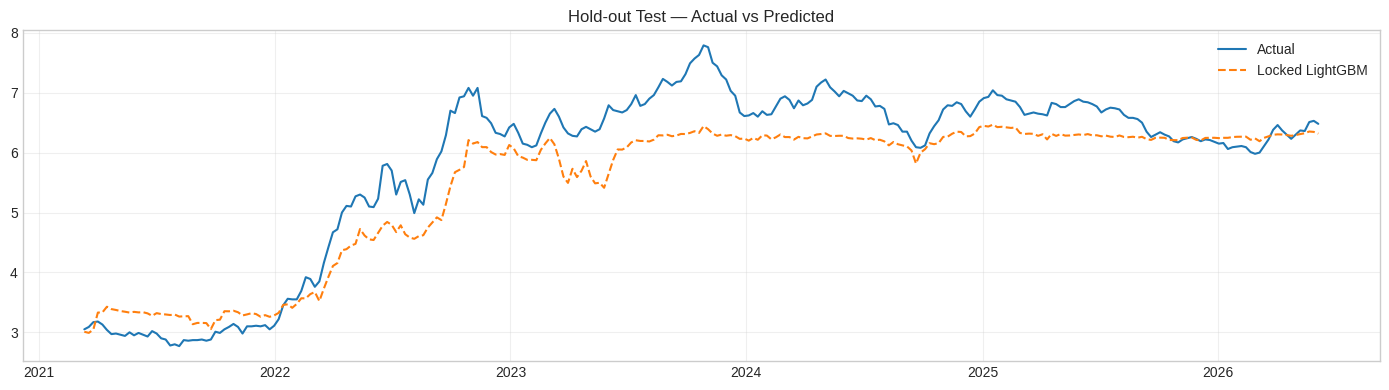

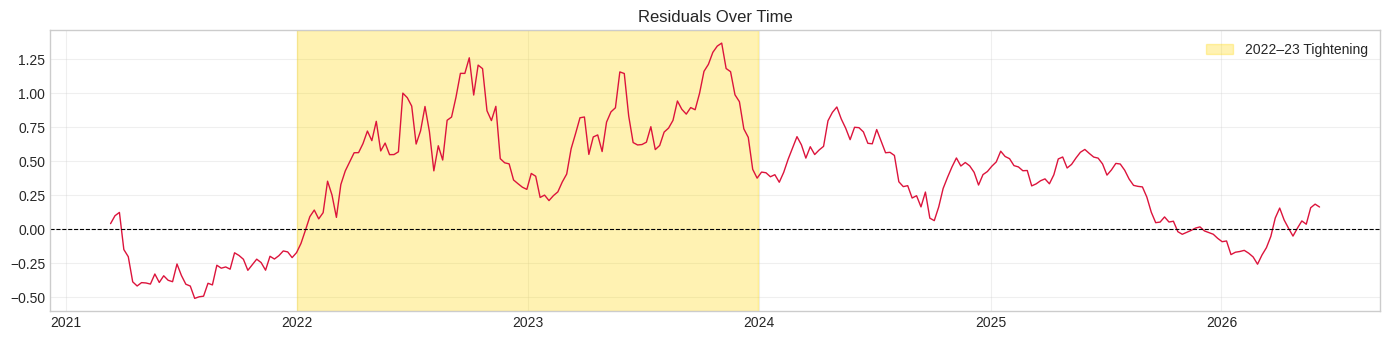

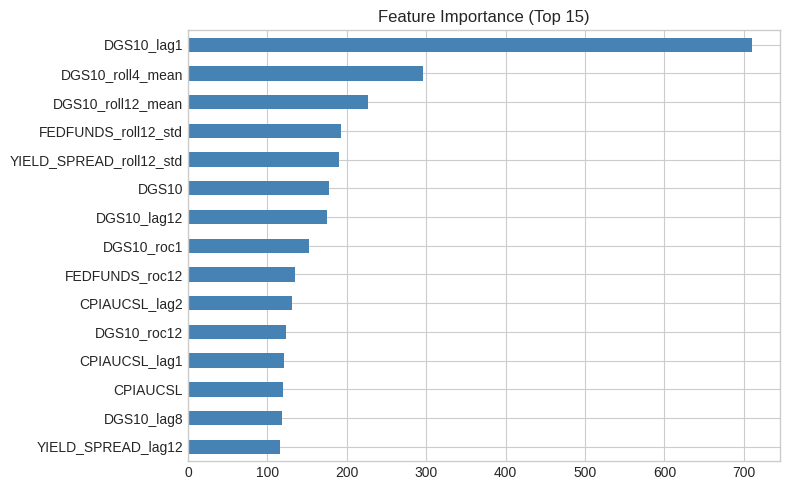

In [6]:
# Actual vs Predicted
plt.figure(figsize=(14, 4))
plt.plot(y_te.index, y_te, label='Actual')
plt.plot(y_te.index, y_pred, label='Locked LightGBM', ls='--')
plt.title('Hold-out Test — Actual vs Predicted')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Residuals + tightening window
resid = y_te - y_pred
plt.figure(figsize=(14, 3.5))
plt.plot(resid.index, resid, color='crimson', lw=1)
plt.axhline(0, color='k', ls='--', lw=0.8)
plt.axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.3, label='2022–23 Tightening')
plt.title('Residuals Over Time'); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Importance
imp = pd.Series(final.feature_importances_, index=features).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
imp[::-1].plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Top 15)'); plt.tight_layout(); plt.show()

## 5. Multi-Origin Check (2004, 2011, 2019, 2021)

At each origin: train on all prior data → validate on early post-origin → test on later post-origin.

In [7]:
origins = {'2004': '2004-12-31', '2011': '2011-12-31',
           '2019': '2019-12-31', '2021': '2021-03-05'}
rows = []
for name, origin in origins.items():
    tr = feat[feat.index <= origin]
    post = feat[feat.index > origin]
    if len(post) < 40:
        continue
    n_val = int(len(post) * 0.67)
    va, te = post.iloc[:n_val], post.iloc[n_val:]
    if len(te) < 10:
        continue
    m = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.03, max_depth=6,
                          num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                          random_state=42, verbosity=-1)
    m.fit(tr[features], tr[TARGET], eval_set=[(va[features], va[TARGET])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    pred = m.predict(te[features])
    rows.append({
        'Origin': name,
        'Test N': len(te),
        'Best iter': m.best_iteration_,
        'Test MSE': round(mean_squared_error(te[TARGET], pred), 3),
        'Test R²': round(r2_score(te[TARGET], pred), 3),
        'Mean resid': round((te[TARGET] - pred).mean(), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))

Origin  Test N  Best iter  Test MSE  Test R²  Mean resid
  2004     369        211     2.393    0.145      -0.469
  2011     249        906     0.376    0.724       0.204
  2019     111        335     0.160   -0.654       0.280
  2021      91        284     0.110   -0.306       0.227


## 6. What the Data Say

| Finding | Evidence |
|---------|----------|
| Exogenous macro features carry real signal | Clean hold-out R² ≈ 0.85 |
| Target lags/rolls are leakage | Ablation: R² jumps to 0.98-0.99; corr(roll4_mean, target) ≈ 0.997 |
| Errors concentrate in rapid tightening | Residuals large and positive in 2022–2023 |
| Performance is era-dependent | Multi-origin: strong at 2011; weak on short late plateaus |
| Hypothesis supported | Clean model > linear/SARIMAX; importance ranks are economic (DGS10, FEDFUNDS, spreads) |

**Locked artifact:** exogenous-only LightGBM from Cell 6.  
**Next:** hyperparameter polish and formal write-up (preprocessing addendum + baseline report).

A leakage-free pipeline that aligns mixed-frequency FRED series to weekly frequency and engineers only exogenous lags, rolling statistics, rate-of-change, and regime flags produces a LightGBM hold-out R² of 0.85. Ablation shows that adding target-derived lags or rolling means inflates R² to 0.98–0.99; the 4-week rolling mean of the mortgage rate correlates 0.997 with the contemporaneous target. Residual analysis localizes the main error to the 2022–2023 tightening episode, consistent with the structural-break and professional-forecast literature. Multi-origin checks show the same pipeline is strong when the test window contains meaningful variation (e.g., origin 2011) and weaker on short elevated plateaus. The hypothesis that exogenous macro series contain usable predictive content for the 30-year mortgage rate is supported; claims based on target-derived features are not.

Lagged cross-correlation: corr(MORTGAGE30US_t, series_{t-k})
    DGS10  FEDFUNDS  UNRATE  CPIAUCSL  HOUST  YIELD_SPREAD
0   0.958     0.812  -0.367    -0.156  0.382        -0.311
1   0.960     0.812  -0.371    -0.154  0.386        -0.309
2   0.957     0.811  -0.374    -0.152  0.391        -0.310
3   0.954     0.811  -0.378    -0.150  0.396        -0.313
4   0.950     0.810  -0.381    -0.148  0.401        -0.316
5   0.946     0.809  -0.384    -0.146  0.406        -0.318
6   0.942     0.809  -0.388    -0.144  0.410        -0.321
7   0.937     0.808  -0.391    -0.142  0.414        -0.324
8   0.933     0.807  -0.394    -0.140  0.417        -0.326
9   0.929     0.806  -0.397    -0.138  0.421        -0.329
10  0.925     0.805  -0.401    -0.136  0.425        -0.331
11  0.921     0.804  -0.404    -0.135  0.428        -0.333
12  0.917     0.803  -0.407    -0.133  0.431        -0.335
13  0.913     0.801  -0.410    -0.131  0.434        -0.337
14  0.909     0.800  -0.413    -0.129  0.437        -0

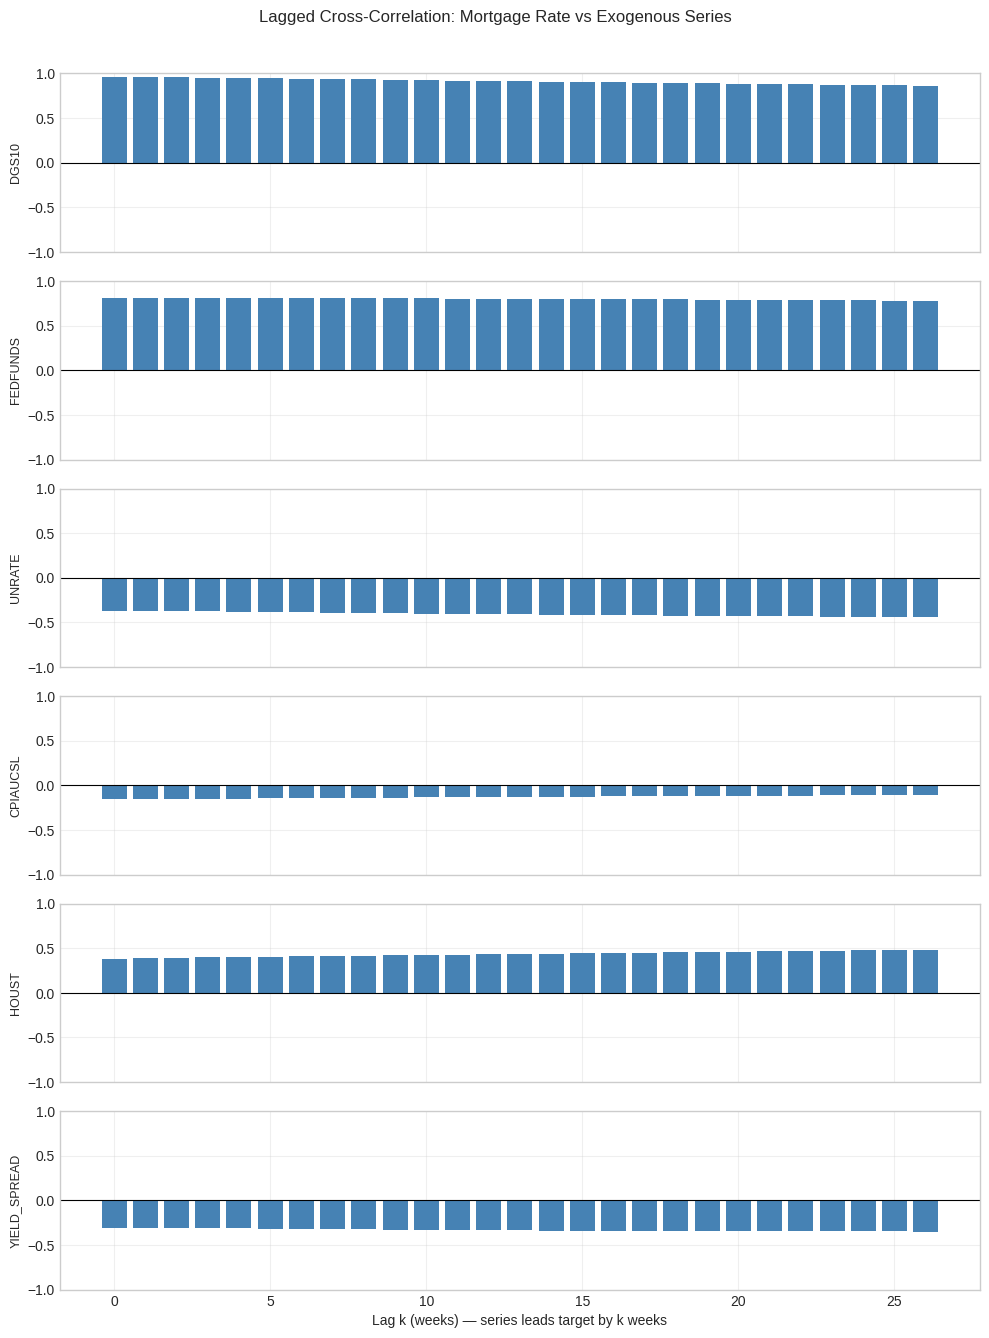


Best lag (by |corr|) per series
              best_lag  corr_at_best_lag  corr_lag0  corr_lag1  corr_lag4  \
DGS10                1             0.960      0.958      0.960      0.950   
FEDFUNDS             0             0.812      0.812      0.812      0.810   
UNRATE              26            -0.440     -0.367     -0.371     -0.381   
CPIAUCSL             0            -0.156     -0.156     -0.154     -0.148   
HOUST               26             0.483      0.382      0.386      0.401   
YIELD_SPREAD        26            -0.350     -0.311     -0.309     -0.316   

              corr_lag12  
DGS10              0.917  
FEDFUNDS           0.803  
UNRATE            -0.407  
CPIAUCSL          -0.133  
HOUST              0.431  
YIELD_SPREAD      -0.335  


In [8]:
# Lagged Cross-Correlation Analysis
# corr(target_t, series_{t-k}) for k = 0..max_lag
# Positive k = past values of the series vs current target

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def lagged_cross_corr(y, x, max_lag=26):
    """Return Series indexed by lag k: corr(y_t, x_{t-k})."""
    y = pd.Series(y).astype(float)
    x = pd.Series(x).astype(float)
    out = {}
    for k in range(0, max_lag + 1):
        if k == 0:
            out[k] = y.corr(x)
        else:
            out[k] = y.corr(x.shift(k))
    return pd.Series(out, name='corr')

# Use the aligned weekly frame (before or after dropna is fine;
# prefer the same grid you model on)
# If you have `feat`, use that; else use `df` after alignment + ffill
base = feat.copy() if 'feat' in dir() else df.copy()

# Core exogenous series to examine against the target
series_list = ['DGS10', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'HOUST', 'YIELD_SPREAD']
# YIELD_SPREAD may only exist on feat
series_list = [s for s in series_list if s in base.columns]

max_lag = 26  # ~ half a year of weeks
cc_table = pd.DataFrame({
    s: lagged_cross_corr(base[TARGET], base[s], max_lag=max_lag)
    for s in series_list
})

print("Lagged cross-correlation: corr(MORTGAGE30US_t, series_{t-k})")
print(cc_table.round(3))

# --- Plot: one panel per series ---
n = len(series_list)
fig, axes = plt.subplots(n, 1, figsize=(10, 2.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, s in zip(axes, series_list):
    ax.bar(cc_table.index, cc_table[s], color='steelblue', width=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel(s, fontsize=9)
    ax.set_ylim(-1, 1)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Lag k (weeks) — series leads target by k weeks')
fig.suptitle('Lagged Cross-Correlation: Mortgage Rate vs Exogenous Series', y=1.01)
plt.tight_layout()
plt.show()

# --- Summary: best lag per series ---
summary = pd.DataFrame({
    'best_lag': cc_table.abs().idxmax(),
    'corr_at_best_lag': [cc_table.loc[cc_table[s].abs().idxmax(), s] for s in series_list],
    'corr_lag0': cc_table.loc[0],
    'corr_lag1': cc_table.loc[1] if 1 in cc_table.index else np.nan,
    'corr_lag4': cc_table.loc[4] if 4 in cc_table.index else np.nan,
    'corr_lag12': cc_table.loc[12] if 12 in cc_table.index else np.nan,
})
print("\nBest lag (by |corr|) per series")
print(summary.round(3))

In [9]:
# Same idea for selected engineered columns
eng_list = [c for c in [
    'DGS10_lag1', 'DGS10_roc4', 'FEDFUNDS_roll12_std',
    'YIELD_SPREAD_roll12_std', 'tightening_flag', 'DGS10_vol12'
] if c in base.columns]

if eng_list:
    cc_eng = pd.DataFrame({
        s: lagged_cross_corr(base[TARGET], base[s], max_lag=12)
        for s in eng_list
    })
    print("\nEngineered features — lagged cross-corr (lags 0–12)")
    print(cc_eng.round(3))


Engineered features — lagged cross-corr (lags 0–12)
    DGS10_lag1  DGS10_roc4  FEDFUNDS_roll12_std  YIELD_SPREAD_roll12_std  \
0        0.960      -0.019                0.318                    0.340   
1        0.957       0.008                0.320                    0.342   
2        0.954       0.014                0.322                    0.343   
3        0.950       0.019                0.323                    0.344   
4        0.946       0.021                0.324                    0.345   
5        0.942       0.022                0.325                    0.346   
6        0.938       0.022                0.327                    0.347   
7        0.933       0.022                0.329                    0.348   
8        0.929       0.021                0.331                    0.350   
9        0.925       0.021                0.333                    0.351   
10       0.921       0.022                0.335                    0.353   
11       0.918       0.022         

Lagged cross-correlations on the frequency-aligned weekly series show that the 10-year Treasury yield is tightly associated with the mortgage rate at short leads (corr ≈ 0.96 at lags 0–1), with a gradual decay at longer lags. The federal funds rate exhibits a similarly strong and persistent association (corr ≈ 0.81). Housing starts and unemployment display moderate associations that strengthen at longer lags, supporting retention of 8- and 12-week lags. CPI and the yield spread show weaker linear links. Among engineered features, DGS10_lag1 inherits the strong Treasury signal; volatility and tightening indicators show modest linear correlation but remain justified as regime markers. These patterns align with the clean model’s feature-importance ranking and with the hypothesis that exogenous macro series carry predictive content for the mortgage rate.

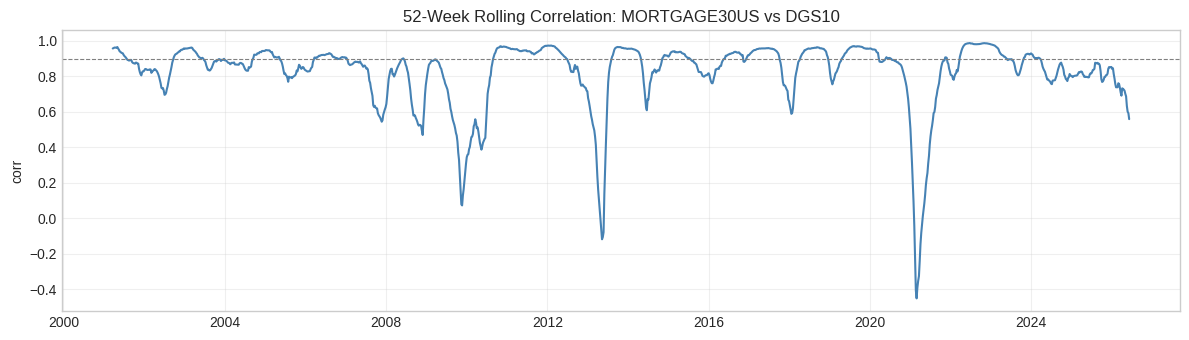

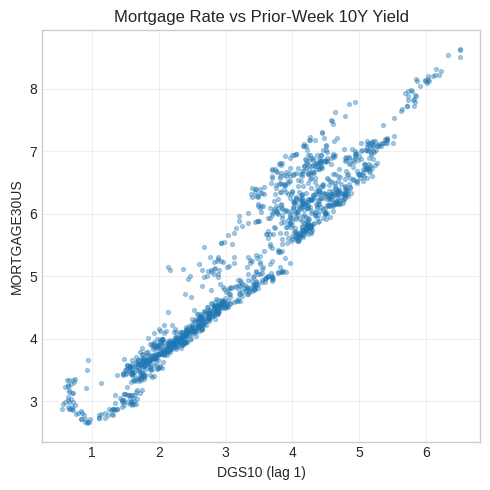

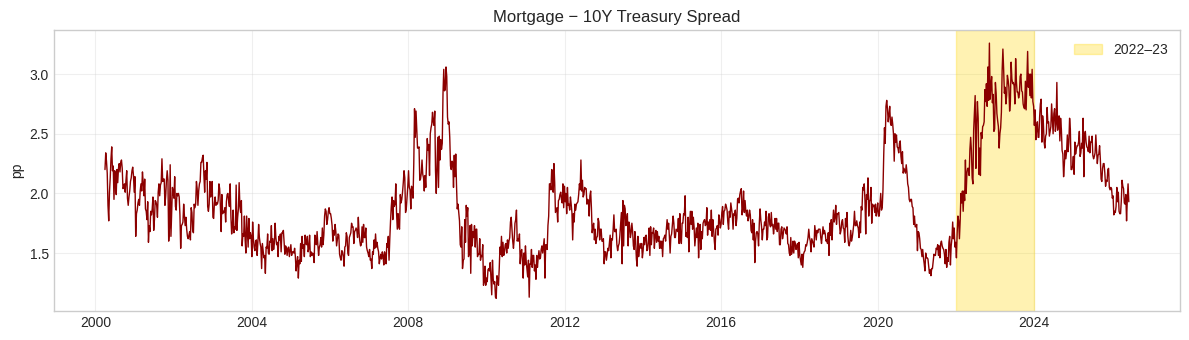

count   1367.000
mean       1.887
std        0.396
min        1.120
25%        1.600
50%        1.780
75%        2.080
max        3.260
dtype: float64


In [10]:
# 1. Rolling 52-week correlation
roll_corr = (
    base[TARGET].rolling(52)
    .corr(base['DGS10'])
)
plt.figure(figsize=(12, 3.5))
plt.plot(roll_corr.index, roll_corr, color='steelblue')
plt.axhline(0.9, color='gray', ls='--', lw=0.8)
plt.title('52-Week Rolling Correlation: MORTGAGE30US vs DGS10')
plt.ylabel('corr'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 2. Scatter at best lag (lag 1)
plt.figure(figsize=(5, 5))
plt.scatter(base['DGS10'].shift(1), base[TARGET], s=8, alpha=0.35)
plt.xlabel('DGS10 (lag 1)'); plt.ylabel('MORTGAGE30US')
plt.title('Mortgage Rate vs Prior-Week 10Y Yield')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 3. Mortgage–Treasury spread over time (the residual channel)
spread = base[TARGET] - base['DGS10']
plt.figure(figsize=(12, 3.5))
plt.plot(spread.index, spread, color='darkred', lw=1)
plt.axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.3, label='2022–23')
plt.title('Mortgage − 10Y Treasury Spread')
plt.ylabel('pp'); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(spread.describe().round(3))

The mortgage rate and the prior-week 10-year Treasury yield are tightly linearly associated (scatter nearly collinear; peak lagged correlation ≈ 0.96). The mortgage–Treasury spread averages about 1.9 percentage points but rose above 3 percentage points during 2022–2023; that widening explains the model’s concentrated under-prediction in the tightening window despite strong Treasury-based signal.

In [11]:
# Spread already = MORTGAGE30US - DGS10
spread = base[TARGET] - base['DGS10']
spread.name = 'MORT_TREAS_SPREAD'

drivers = ['DGS10', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'HOUST', 'YIELD_SPREAD']
# Engineered if present
extra = [c for c in [
    'DGS10_vol12', 'FEDFUNDS_roll12_std', 'YIELD_SPREAD_roll12_std',
    'FEDFUNDS_change_12w', 'tightening_flag', 'DGS10_roc4', 'FEDFUNDS_roc4'
] if c in base.columns]

all_drivers = drivers + extra

# Contemporaneous correlation with the spread
spread_corr = pd.Series({
    c: spread.corr(base[c]) for c in all_drivers if c in base.columns
}).sort_values(key=lambda s: s.abs(), ascending=False)

print("Correlation with Mortgage–Treasury Spread")
print(spread_corr.round(3))

# Lagged cross-corr: does past vol/policy lead the spread?
def lagged_cc(y, x, max_lag=12):
    return pd.Series({k: y.corr(x.shift(k)) for k in range(0, max_lag+1)})

focus = [c for c in ['DGS10_vol12', 'FEDFUNDS_roll12_std', 'FEDFUNDS_change_12w',
                     'tightening_flag', 'UNRATE', 'HOUST'] if c in base.columns]

print("\nLagged corr(spread_t, driver_{t-k})")
for c in focus:
    cc = lagged_cc(spread, base[c], max_lag=12)
    print(f"\n{c}")
    print(cc.round(3).to_string())

Correlation with Mortgage–Treasury Spread
YIELD_SPREAD              -0.502
CPIAUCSL                   0.453
FEDFUNDS                   0.415
FEDFUNDS_roll12_std        0.401
YIELD_SPREAD_roll12_std    0.357
DGS10_vol12                0.355
UNRATE                    -0.250
tightening_flag            0.224
DGS10_roc4                -0.186
DGS10                      0.123
FEDFUNDS_change_12w       -0.080
FEDFUNDS_roc4             -0.044
HOUST                      0.019
dtype: float64

Lagged corr(spread_t, driver_{t-k})

DGS10_vol12
0    0.355
1    0.352
2    0.343
3    0.334
4    0.324
5    0.317
6    0.311
7    0.304
8    0.298
9    0.290
10   0.284
11   0.275
12   0.262

FEDFUNDS_roll12_std
0    0.401
1    0.407
2    0.413
3    0.413
4    0.411
5    0.407
6    0.406
7    0.404
8    0.399
9    0.395
10   0.393
11   0.391
12   0.389

FEDFUNDS_change_12w
0    -0.080
1    -0.075
2    -0.075
3    -0.070
4    -0.067
5    -0.060
6    -0.053
7    -0.049
8    -0.038
9    -0.031
10   -0.025
11  

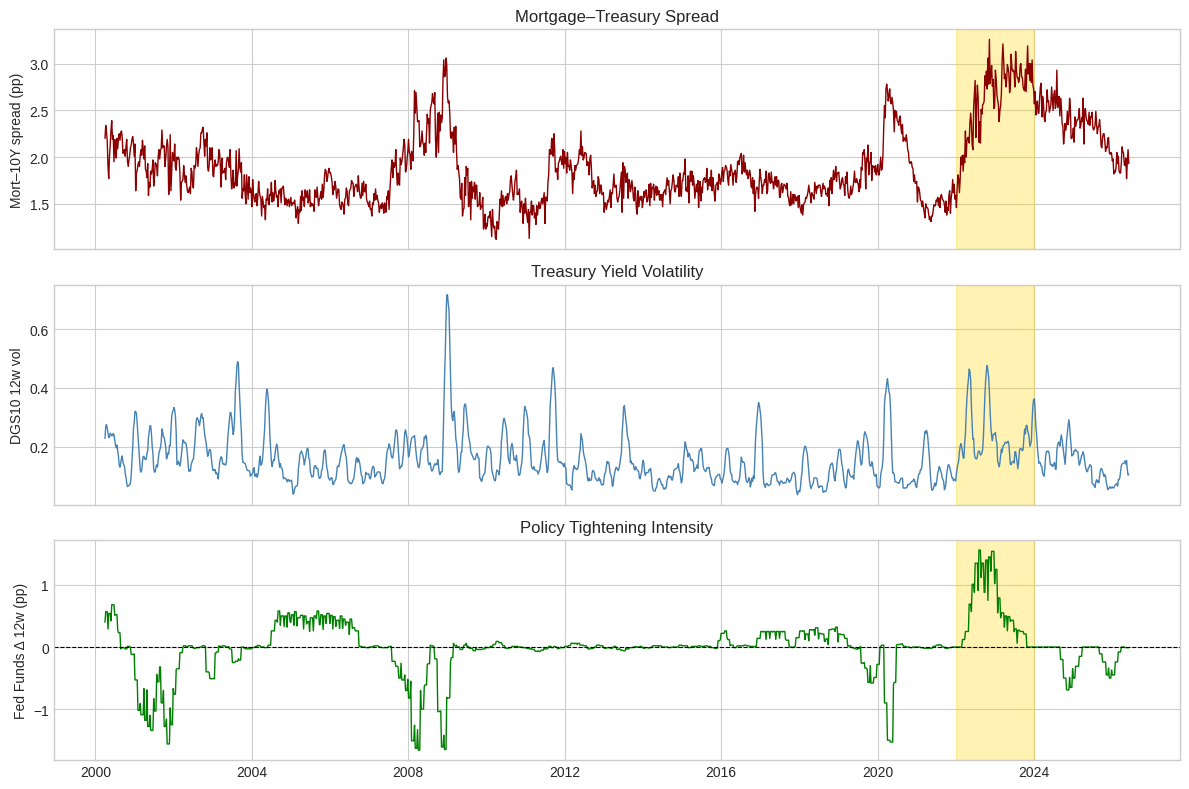

In [12]:
# Visual: spread vs vol side by side
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(spread.index, spread, color='darkred', lw=1)
axes[0].axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.3)
axes[0].set_ylabel('Mort–10Y spread (pp)')
axes[0].set_title('Mortgage–Treasury Spread')

if 'DGS10_vol12' in base.columns:
    axes[1].plot(base.index, base['DGS10_vol12'], color='steelblue', lw=1)
    axes[1].axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.3)
    axes[1].set_ylabel('DGS10 12w vol')
    axes[1].set_title('Treasury Yield Volatility')

if 'FEDFUNDS_change_12w' in base.columns:
    axes[2].plot(base.index, base['FEDFUNDS_change_12w'], color='green', lw=1)
    axes[2].axhline(0, color='k', ls='--', lw=0.8)
    axes[2].axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.3)
    axes[2].set_ylabel('Fed Funds Δ 12w (pp)')
    axes[2].set_title('Policy Tightening Intensity')

plt.tight_layout()
plt.show()

In [13]:
# Simple linear attribution on the spread (explanatory, not forecasting)
from sklearn.linear_model import LinearRegression

spread_df = base[all_drivers].copy()
spread_df['spread'] = spread
spread_df = spread_df.dropna()

X_s = spread_df[all_drivers]
y_s = spread_df['spread']
# standardize for comparable coefficients
X_z = (X_s - X_s.mean()) / X_s.std()
lr = LinearRegression().fit(X_z, y_s)
coef = pd.Series(lr.coef_, index=all_drivers).sort_values(key=lambda s: s.abs(), ascending=False)
print("\nStandardized linear coefficients for spread")
print(coef.round(3))
print(f"R² (in-sample explanatory): {lr.score(X_z, y_s):.3f}")


Standardized linear coefficients for spread
CPIAUCSL                   0.175
DGS10_vol12                0.108
YIELD_SPREAD              -0.087
FEDFUNDS_roll12_std        0.071
FEDFUNDS                   0.067
DGS10_roc4                -0.063
UNRATE                     0.044
FEDFUNDS_change_12w       -0.038
tightening_flag            0.030
YIELD_SPREAD_roll12_std    0.022
FEDFUNDS_roc4              0.013
DGS10                      0.013
HOUST                     -0.001
dtype: float64
R² (in-sample explanatory): 0.597


The mortgage–Treasury spread averages 1.9 percentage points and exceeded 3 percentage points in 2022–2023. Contemporaneous and lagged correlations show that spread widening is associated with higher policy and Treasury volatility, higher CPI, and higher Fed Funds levels (absolute correlations ~0.35–0.50). A simple linear combination of these drivers explains about 60% of spread variation in-sample. This supports retaining volatility and tightening indicators in the feature set, and it explains why a model driven primarily by Treasury yield lags under-predicts mortgage rates when the spread regime shifts even if it tracks DGS10 closely.

In [14]:
# Zesty
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

TARGET = 'MORTGAGE30US'

regime_cols = [c for c in [
    'tightening_flag', 'FEDFUNDS_change_12w', 'DGS10_vol12',
    'FEDFUNDS_roll12_std', 'YIELD_SPREAD_roll12_std',
    'DGS10_roll4_std', 'DGS10_roll12_std', 'FEDFUNDS_roll4_std'
] if c in feat.columns]

base_cols = [c for c in feat.columns if c != TARGET and c not in regime_cols]
all_cols  = base_cols + regime_cols

split_idx = int(len(feat) * 0.80)
train, test = feat.iloc[:split_idx], feat.iloc[split_idx:]

# 2022-2023 mask on test
mask_tt = (test.index >= '2022-01-01') & (test.index <= '2023-12-31')

def fit_lgb(X_tr, y_tr, X_te):
    m = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
    )
    m.fit(X_tr, y_tr)
    return m, m.predict(X_te)

def report(name, y_true, y_pred, mask=None):
    mse = mean_squared_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    resid = y_true - y_pred
    row = {
        'Model': name,
        'Test MSE': round(mse, 3),
        'Test R²': round(r2, 3),
        'Mean resid': round(resid.mean(), 3),
    }
    if mask is not None and mask.sum() > 0:
        row['2022-23 mean resid'] = round(resid[mask].mean(), 3)
        row['2022-23 MSE'] = round(mean_squared_error(y_true[mask], y_pred[mask]), 3)
    return row

In [15]:
print("1. Regime ablation")
rows = []

# Without regime
m0, pred0 = fit_lgb(train[base_cols], train[TARGET], test[base_cols])
rows.append(report('Without regime/vol', test[TARGET], pred0, mask_tt))

# With regime
m1, pred1 = fit_lgb(train[all_cols], train[TARGET], test[all_cols])
rows.append(report('With regime/vol', test[TARGET], pred1, mask_tt))

ablation_df = pd.DataFrame(rows)
print(ablation_df.to_string(index=False))

1. Regime ablation
             Model  Test MSE  Test R²  Mean resid  2022-23 mean resid  2022-23 MSE
Without regime/vol     0.343    0.833       0.395               0.735        0.639
   With regime/vol     0.322    0.844       0.380               0.682        0.571


In [16]:
print("\n2. Two-step (level + spread)")

# Step A: level model driven mainly by Treasury-related features
treasury_cols = [c for c in base_cols if any(k in c for k in
    ['DGS10', 'YIELD_SPREAD', 'FEDFUNDS', 'CPIAUCSL', 'UNRATE', 'HOUST'])]
# prefer pure treasury-ish if you want a stricter level model:
# treasury_cols = [c for c in base_cols if 'DGS10' in c or c in ['FEDFUNDS','YIELD_SPREAD','CPIAUCSL']]

m_level, level_pred_te = fit_lgb(train[treasury_cols], train[TARGET], test[treasury_cols])
level_pred_tr = m_level.predict(train[treasury_cols])

# Spread residual in train / test
spread_tr = train[TARGET] - level_pred_tr
spread_te = test[TARGET] - level_pred_te

# Step B: model the residual/spread with regime/vol features + optional base
spread_feats = regime_cols if len(regime_cols) else base_cols
# add a couple of level drivers for stability
spread_feats = list(dict.fromkeys(spread_feats + [c for c in ['DGS10', 'FEDFUNDS', 'CPIAUCSL'] if c in feat.columns]))

m_spread, spread_pred_te = fit_lgb(train[spread_feats], spread_tr, test[spread_feats])

# Combined forecast
two_step_pred = level_pred_te + spread_pred_te

rows2 = [
    report('Level only (Treasury-heavy)', test[TARGET], level_pred_te, mask_tt),
    report('Two-step (level + spread)', test[TARGET], two_step_pred, mask_tt),
]
print(pd.DataFrame(rows2).to_string(index=False))


2. Two-step (level + spread)
                      Model  Test MSE  Test R²  Mean resid  2022-23 mean resid  2022-23 MSE
Level only (Treasury-heavy)     0.343    0.833       0.395               0.735        0.639
  Two-step (level + spread)     0.341    0.834       0.395               0.732        0.633


In [17]:
print("\n3. Regime-conditional")

# Define stress on training data (same rule as tightening_flag if present)
if 'tightening_flag' in feat.columns:
    stress_tr = train['tightening_flag'] == 1
    stress_te = test['tightening_flag'] == 1
else:
    # fallback: high vol regime
    vol_col = 'DGS10_vol12' if 'DGS10_vol12' in feat.columns else None
    if vol_col:
        thr = train[vol_col].quantile(0.75)
        stress_tr = train[vol_col] >= thr
        stress_te = test[vol_col] >= thr
    else:
        raise ValueError('Need tightening_flag or DGS10_vol12')

# Calm model
m_calm, _ = fit_lgb(
    train.loc[~stress_tr, all_cols],
    train.loc[~stress_tr, TARGET],
    test[all_cols]  # predict all; we'll select
)
pred_calm = m_calm.predict(test[all_cols])

# Stress model (if enough rows)
if stress_tr.sum() >= 50:
    m_stress, _ = fit_lgb(
        train.loc[stress_tr, all_cols],
        train.loc[stress_tr, TARGET],
        test[all_cols]
    )
    pred_stress = m_stress.predict(test[all_cols])
else:
    print('Too few stress weeks in train; using calm model only for stress weeks')
    pred_stress = pred_calm

# Combine by regime at test time
cond_pred = np.where(stress_te, pred_stress, pred_calm)

rows3 = [
    report('Single model (with regime)', test[TARGET], pred1, mask_tt),
    report('Regime-conditional', test[TARGET], cond_pred, mask_tt),
]
print(pd.DataFrame(rows3).to_string(index=False))
print(f"Train stress weeks: {stress_tr.sum()} | Test stress weeks: {stress_te.sum()}")


3. Regime-conditional
Too few stress weeks in train; using calm model only for stress weeks
                     Model  Test MSE  Test R²  Mean resid  2022-23 mean resid  2022-23 MSE
Single model (with regime)     0.322    0.844       0.380               0.682        0.571
        Regime-conditional     0.331    0.840       0.376               0.689        0.581
Train stress weeks: 43 | Test stress weeks: 46


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# State features available at t (no target leakage)
state_cols = [c for c in [
    'FEDFUNDS_change_12w', 'DGS10_vol12', 'FEDFUNDS_roll12_std',
    'YIELD_SPREAD', 'YIELD_SPREAD_roll12_std', 'DGS10_roc4'
] if c in feat.columns]

state = feat[state_cols].dropna()
scaler = StandardScaler()
Z = scaler.fit_transform(state)

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(Z)

# Soft regime: probability of the "high-stress" component
probs = gmm.predict_proba(Z)
# Identify which component is stress (higher mean vol / Fed change)
means = pd.DataFrame(scaler.inverse_transform(gmm.means_), columns=state_cols)
stress_comp = means['DGS10_vol12'].idxmax() if 'DGS10_vol12' in means.columns else means.iloc[:, 0].idxmax()
feat.loc[state.index, 'stress_prob'] = probs[:, stress_comp]
feat.loc[state.index, 'stress_label'] = (feat.loc[state.index, 'stress_prob'] >= 0.5).astype(int)

print('GMM component means (original scale):')
print(means.round(3))
print('\nStress component:', stress_comp)
print(feat[['stress_prob', 'stress_label']].describe())

GMM component means (original scale):
   FEDFUNDS_change_12w  DGS10_vol12  FEDFUNDS_roll12_std  YIELD_SPREAD  \
0               -0.001        0.145                0.007         1.622   
1               -0.037        0.177                0.171         0.957   

   YIELD_SPREAD_roll12_std  DGS10_roc4  
0                    0.146       0.002  
1                    0.229       0.005  

Stress component: 1
       stress_prob  stress_label
count     1367.000      1367.000
mean         0.475         0.473
std          0.497         0.499
min          0.000         0.000
25%          0.000         0.000
50%          0.010         0.000
75%          1.000         1.000
max          1.000         1.000


In [19]:
# Compare unsupervised label vs hand-crafted flag
if 'tightening_flag' in feat.columns:
    ct = pd.crosstab(
        feat['tightening_flag'].fillna(-1),
        feat['stress_label'].fillna(-1),
        rownames=['hand_flag'],
        colnames=['gmm_label']
    )
    print('\nHand flag vs GMM label:')
    print(ct)


Hand flag vs GMM label:
gmm_label  0.000  1.000
hand_flag              
0            720    558
1              0     89


In [20]:
# Assumes feat has: stress_prob, stress_label, tightening_flag, TARGET
# and chronological train/test, mask_tt for 2022-23

core = [c for c in feat.columns if c not in [
    TARGET, 'tightening_flag', 'stress_prob', 'stress_label',
    'FEDFUNDS_change_12w', 'DGS10_vol12', 'FEDFUNDS_roll12_std',
    'YIELD_SPREAD_roll12_std', 'DGS10_roll4_std', 'DGS10_roll12_std',
    'FEDFUNDS_roll4_std'
] and c in feat.columns]

# Keep non-regime engineered features in core
# or build core explicitly from your known clean list minus regime cols.

configs = {
    'A. No regime': core,
    'B. Hand flag only': core + [c for c in ['tightening_flag'] if c in feat.columns],
    'C. GMM stress_prob only': core + [c for c in ['stress_prob'] if c in feat.columns],
    'D. Hand + GMM': core + [c for c in ['tightening_flag', 'stress_prob'] if c in feat.columns],
}

rows = []
for name, cols in configs.items():
    cols = [c for c in cols if c in train.columns]
    m, pred = fit_lgb(train[cols], train[TARGET], test[cols])
    rows.append(report(name, test[TARGET], pred, mask_tt))

print(pd.DataFrame(rows).to_string(index=False))

                  Model  Test MSE  Test R²  Mean resid  2022-23 mean resid  2022-23 MSE
           A. No regime     0.343    0.833       0.395               0.735        0.639
      B. Hand flag only     0.336    0.837       0.378               0.724        0.629
C. GMM stress_prob only     0.343    0.833       0.395               0.735        0.639
          D. Hand + GMM     0.336    0.837       0.378               0.724        0.629


In [21]:
# Lagged cross-corr for candidates already on feat/df
candidates = [c for c in [
    'DGS10', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'HOUST', 'YIELD_SPREAD',
    'DGS10_vol12', 'stress_prob'
] if c in feat.columns]

def best_lead(y, x, max_lag=26):
    corrs = {k: y.corr(x.shift(k)) for k in range(0, max_lag+1)}
    s = pd.Series(corrs)
    k = s.abs().idxmax()
    return k, s.loc[k], s.loc[1] if 1 in s.index else np.nan, s.loc[12] if 12 in s.index else np.nan

lead_rows = []
for c in candidates:
    k, cbest, c1, c12 = best_lead(feat[TARGET], feat[c], max_lag=26)
    lead_rows.append({
        'series': c, 'best_lag': k, 'corr_best': round(cbest, 3),
        'corr_lag1': round(c1, 3) if pd.notna(c1) else None,
        'corr_lag12': round(c12, 3) if pd.notna(c12) else None,
    })
print(pd.DataFrame(lead_rows).sort_values('corr_best', key=lambda s: s.abs(), ascending=False))

         series  best_lag  corr_best  corr_lag1  corr_lag12
0         DGS10         1      0.960      0.960       0.917
1      FEDFUNDS         0      0.812      0.812       0.803
4         HOUST        26      0.483      0.386       0.431
2        UNRATE        26     -0.440     -0.371      -0.407
7   stress_prob        11      0.368      0.349       0.368
5  YIELD_SPREAD        26     -0.350     -0.309      -0.335
6   DGS10_vol12        25      0.242      0.241       0.223
3      CPIAUCSL         0     -0.156     -0.154      -0.133


In [22]:
# Optional: pull a few more FRED series and test leads
import requests
from io import StringIO

extra_ids = ['DGS2', 'T10Y2Y', 'PERMIT', 'MSACSR', 'ICSA', 'VIXCLS']
# ICSA is weekly; others monthly/daily

def fred_csv(series_id):
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    r = requests.get(url, timeout=20)
    r.raise_for_status()
    d = pd.read_csv(StringIO(r.text), parse_dates=['observation_date'])
    d = d.rename(columns={'observation_date': 'date', series_id: series_id}).set_index('date').sort_index()
    return d

extra = {}
for sid in extra_ids:
    try:
        extra[sid] = fred_csv(sid)
        print('loaded', sid, extra[sid].shape)
    except Exception as e:
        print('skip', sid, e)

# Align to weekly grid of feat
weekly_idx = feat.index
extra_w = pd.DataFrame(index=weekly_idx)
for sid, d in extra.items():
    s = d[sid].resample('W-FRI').last()
    extra_w[sid] = s.reindex(weekly_idx).ffill()

# Lead table for extras vs target
y = feat[TARGET].reindex(weekly_idx)
extra_lead = []
for c in extra_w.columns:
    k, cbest, c1, c12 = best_lead(y, extra_w[c], max_lag=26)
    extra_lead.append({
        'series': c, 'best_lag': k, 'corr_best': round(cbest, 3),
        'corr_lag1': round(c1, 3) if pd.notna(c1) else None,
        'corr_lag12': round(c12, 3) if pd.notna(c12) else None,
    })
print('\n=== Extra FRED leads ===')
print(pd.DataFrame(extra_lead).sort_values('corr_best', key=lambda s: s.abs(), ascending=False))

loaded DGS2 (13092, 1)
loaded T10Y2Y (13093, 1)
loaded PERMIT (798, 1)
loaded MSACSR (762, 1)
loaded ICSA (3109, 1)
loaded VIXCLS (9547, 1)

=== Extra FRED leads ===
   series  best_lag  corr_best  corr_lag1  corr_lag12
0    DGS2         2      0.877      0.877       0.866
2  PERMIT        26      0.461      0.356       0.407
1  T10Y2Y        26     -0.373     -0.311      -0.347
3  MSACSR         0      0.248      0.248       0.242
4    ICSA        26     -0.246     -0.201      -0.225
5  VIXCLS         0      0.084      0.080       0.035


In [23]:
# Kitchen-sink FRED leads: commodities + equities

sink_ids = [
    # Commodities / materials
    'PCOPPUSDM',   # Global copper price (Monthly)
    'WPU081',      # PPI lumber & wood (Monthly) — fallback if no spot lumber
    'DCOILWTICO',  # WTI oil (Daily)
    'GOLDAMGBD228NLBM',  # Gold LBMA (Daily)
    # Equities / risk
    'SP500',       # S&P 500 (Daily)
    'NASDAQCOM',   # Nasdaq Composite (Daily)
    'WILL5000PR',  # Wilshire 5000 price (Daily) — broad US
    'RU1000PR',    # Russell 1000 price
    'VIXCLS',      # already tested; keep for comparison
]

sink = {}
for sid in sink_ids:
    try:
        sink[sid] = fred_csv(sid)
        print('loaded', sid, sink[sid].shape)
    except Exception as e:
        print('skip', sid, '->', e)

# Align
weekly_idx = feat.index
sink_w = pd.DataFrame(index=weekly_idx)
for sid, d in sink.items():
    col = sid
    s = d[col].resample('W-FRI').last()
    sink_w[sid] = s.reindex(weekly_idx).ffill()

# Drop all-NaN columns
sink_w = sink_w.dropna(axis=1, how='all')

y = feat[TARGET].reindex(weekly_idx)

def best_lead(y, x, max_lag=26):
    x = x.astype(float)
    corrs = {}
    for k in range(0, max_lag + 1):
        corrs[k] = y.corr(x.shift(k))
    s = pd.Series(corrs).dropna()
    if s.empty:
        return None, np.nan, np.nan, np.nan
    k = s.abs().idxmax()
    return k, float(s.loc[k]), float(s.get(1, np.nan)), float(s.get(12, np.nan))

rows = []
for c in sink_w.columns:
    # need enough overlap
    valid = y.notna() & sink_w[c].notna()
    if valid.sum() < 100:
        print('too short', c)
        continue
    k, cbest, c1, c12 = best_lead(y[valid], sink_w.loc[valid, c], max_lag=26)
    rows.append({
        'series': c,
        'best_lag': k,
        'corr_best': round(cbest, 3) if pd.notna(cbest) else None,
        'corr_lag1': round(c1, 3) if pd.notna(c1) else None,
        'corr_lag12': round(c12, 3) if pd.notna(c12) else None,
        'n': int(valid.sum()),
    })

sink_lead = pd.DataFrame(rows).sort_values('corr_best', key=lambda s: s.abs(), ascending=False)
print('\nKitchen-sink leads vs MORTGAGE30US')
print(sink_lead.to_string(index=False))

loaded PCOPPUSDM (414, 1)
loaded WPU081 (1206, 1)
loaded DCOILWTICO (10588, 1)
skip GOLDAMGBD228NLBM -> 404 Client Error: Not Found for url: https://fred.stlouisfed.org/graph/fredgraph.csv?id=GOLDAMGBD228NLBM
loaded SP500 (2609, 1)
loaded NASDAQCOM (14480, 1)
skip WILL5000PR -> 404 Client Error: Not Found for url: https://fred.stlouisfed.org/graph/fredgraph.csv?id=WILL5000PR
skip RU1000PR -> 404 Client Error: Not Found for url: https://fred.stlouisfed.org/graph/fredgraph.csv?id=RU1000PR
loaded VIXCLS (9547, 1)

Kitchen-sink leads vs MORTGAGE30US
    series  best_lag  corr_best  corr_lag1  corr_lag12    n
     SP500        26      0.661      0.633       0.639  513
 PCOPPUSDM         0     -0.235     -0.233      -0.218 1366
    WPU081         0     -0.201     -0.194      -0.124 1366
DCOILWTICO         0     -0.164     -0.160      -0.142 1367
    VIXCLS         0      0.084      0.080       0.035 1367
 NASDAQCOM        26      0.070      0.022       0.042 1367


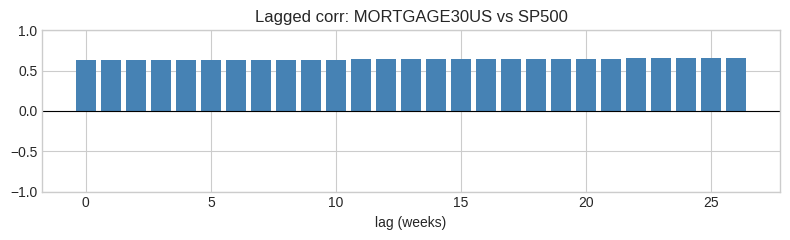

In [24]:
strong = sink_lead[sink_lead['corr_best'].abs() >= 0.25]['series'].tolist()
for c in strong[:4]:
    cc = pd.Series({k: y.corr(sink_w[c].shift(k)) for k in range(0, 27)})
    plt.figure(figsize=(8, 2.5))
    plt.bar(cc.index, cc.values, color='steelblue')
    plt.axhline(0, color='k', lw=0.8)
    plt.title(f'Lagged corr: MORTGAGE30US vs {c}')
    plt.xlabel('lag (weeks)'); plt.ylim(-1, 1)
    plt.tight_layout(); plt.show()

In [25]:
# Overlay: baseline vs baseline + SP500 + copper + lumber


# 1) Align extras to feat index
extra_map = {}
for sid in ['SP500', 'PCOPPUSDM', 'WPU081']:
    if sid in sink_w.columns:
        extra_map[sid] = sink_w[sid]
    else:
        print('missing', sid)

aug = feat.copy()
for sid, s in extra_map.items():
    aug[sid] = s.reindex(aug.index).ffill()

# 2) Simple exogenous lags for the new series
new_base = list(extra_map.keys())
for col in new_base:
    for lag in [1, 2, 4, 8, 12]:
        aug[f'{col}_lag{lag}'] = aug[col].shift(lag)
    aug[f'{col}_roll4_mean'] = aug[col].rolling(4).mean()
    aug[f'{col}_roc4'] = aug[col].pct_change(4)

aug = aug.dropna()
print('Augmented shape:', aug.shape)

# 3) Feature sets
regime_like = [c for c in ['tightening_flag', 'stress_prob'] if c in aug.columns]
# Original clean predictors that still exist on aug
orig_feats = [c for c in features if c in aug.columns and c not in new_base]
# drop raw new cols from "orig" if they leaked in
orig_feats = [c for c in orig_feats if not any(c.startswith(nb) for nb in new_base)]

new_feats = [c for c in aug.columns if any(c.startswith(nb) for nb in new_base)]
combo_feats = orig_feats + new_feats
# optional: include hand flag in both for fairness
for fset in (orig_feats, combo_feats):
    for r in regime_like:
        if r in aug.columns and r not in fset:
            fset.append(r)

# 4) Same chronological split on the augmented frame
split_idx = int(len(aug) * 0.80)
tr, te = aug.iloc[:split_idx], aug.iloc[split_idx:]
mask_tt = (te.index >= '2022-01-01') & (te.index <= '2023-12-31')

def run(name, cols):
    cols = [c for c in cols if c in tr.columns]
    m, pred = fit_lgb(tr[cols], tr[TARGET], te[cols])
    return report(name, te[TARGET], pred, mask_tt)

rows = [
    run('Baseline (orig + flag)', orig_feats),
    run('Baseline + SP500/Cu/Lumber', combo_feats),
]
print(pd.DataFrame(rows).to_string(index=False))
print('\nN orig feats:', len(orig_feats), '| N combo feats:', len(combo_feats))
print('Train', tr.index.min().date(), '→', tr.index.max().date(),
      '| Test', te.index.min().date(), '→', te.index.max().date())

Augmented shape: (501, 88)
                     Model  Test MSE  Test R²  Mean resid
    Baseline (orig + flag)     0.133   -0.623      -0.310
Baseline + SP500/Cu/Lumber     0.115   -0.399      -0.282

N orig feats: 62 | N combo feats: 86
Train 2016-11-04 → 2024-06-28 | Test 2024-07-05 → 2026-06-05


In [26]:
# 5) Optional: importance of the new block only
m_combo, pred_combo = fit_lgb(tr[combo_feats], tr[TARGET], te[combo_feats])
imp = pd.Series(m_combo.feature_importances_, index=combo_feats).sort_values(ascending=False)
print('\nTop 20 importances (combo model):')
print(imp.head(20))
print('\nNew-block importances:')
print(imp[[i for i in imp.index if any(i.startswith(nb) for nb in new_base)]].head(15))


Top 20 importances (combo model):
DGS10_lag1                 259
DGS10_roc1                 172
DGS10_roc2                 149
YIELD_SPREAD_roll4_std     143
DGS10_roll12_mean          130
DGS10                      129
DGS10_roll4_std            121
DGS10_roll12_std           120
YIELD_SPREAD_lag12         118
SP500_lag12                112
SP500_roc4                  99
DGS10_lag4                  96
FEDFUNDS_roll12_std         95
DGS10_roc4                  91
FEDFUNDS_roll4_std          91
YIELD_SPREAD_lag8           85
DGS10_roll4_mean            80
DGS10_roc8                  80
YIELD_SPREAD_roll12_std     68
DGS10_lag2                  67
dtype: int32

New-block importances:
SP500_lag12             112
SP500_roc4               99
SP500_lag1               61
SP500_lag8               50
PCOPPUSDM_lag2           46
WPU081_roc4              44
SP500_lag2               44
WPU081_lag12             39
PCOPPUSDM_roll4_mean     38
SP500_lag4               38
WPU081_lag2              37


In [27]:
# Placebo features: moon phase, simple tide proxy, Niño SST

import numpy as np

placebo = feat.copy()  # full-length FRED frame

# Moon phase proxy: continuous cycle 0-1 over ~29.53 days
# Astronomical phase
days = (placebo.index - placebo.index[0]).days.values.astype(float)
synodic = 29.530588  # days
placebo['moon_phase'] = 0.5 * (1 + np.sin(2 * np.pi * days / synodic))
placebo['moon_phase_lag4'] = placebo['moon_phase'].shift(4)

# Tide proxy: semi-diurnal nonsense aggregated weekly
placebo['tide_proxy'] = 0.5 * (1 + np.sin(2 * np.pi * days / 14.765))
placebo['tide_proxy_lag4'] = placebo['tide_proxy'].shift(4)

# Pacific SST / ENSO
# FRED
try:
    nino = fred_csv('NINO3')
    nino_w = nino.iloc[:, 0].resample('W-FRI').last().reindex(placebo.index).ffill()
    placebo['nino3'] = nino_w
    placebo['nino3_lag12'] = nino_w.shift(12)
    placebo['nino3_lag52'] = nino_w.shift(52)
    climate_cols = ['nino3', 'nino3_lag12', 'nino3_lag52']
except Exception as e:
    print('Niño not loaded:', e)
    climate_cols = []

# Fertilizer
rng = np.random.default_rng(42)
placebo['fert_gas_share_noise'] = rng.normal(0, 1, size=len(placebo))
placebo['fert_gas_share_noise_lag4'] = placebo['fert_gas_share_noise'].shift(4)

placebo_cols = [
    'moon_phase', 'moon_phase_lag4',
    'tide_proxy', 'tide_proxy_lag4',
    'fert_gas_share_noise', 'fert_gas_share_noise_lag4',
] + climate_cols

placebo = placebo.dropna()
print('Placebo frame:', placebo.shape)

# Feature sets on common index
base_cols = [c for c in features if c in placebo.columns]
plus_placebo = base_cols + [c for c in placebo_cols if c in placebo.columns]

split_idx = int(len(placebo) * 0.80)
tr, te = placebo.iloc[:split_idx], placebo.iloc[split_idx:]
mask_tt = (te.index >= '2022-01-01') & (te.index <= '2023-12-31')

rows = [
    run('Baseline only', base_cols) if 'run' in dir() else None,
]
# inline
def _run(name, cols):
    cols = [c for c in cols if c in tr.columns]
    m, pred = fit_lgb(tr[cols], tr[TARGET], te[cols])
    return report(name, te[TARGET], pred, mask_tt)

rows = [
    _run('Baseline only', base_cols),
    _run('Baseline + placebos', plus_placebo),
]
print(pd.DataFrame(rows).to_string(index=False))


m_p, _ = fit_lgb(tr[plus_placebo], tr[TARGET], te[plus_placebo])
imp = pd.Series(m_p.feature_importances_, index=plus_placebo).sort_values(ascending=False)
print('\nPlacebo-block importances:')
print(imp[[i for i in imp.index if i in placebo_cols]])
print('\nTop 10 overall:')
print(imp.head(10))

Niño not loaded: 404 Client Error: Not Found for url: https://fred.stlouisfed.org/graph/fredgraph.csv?id=NINO3
Placebo frame: (1363, 70)
              Model  Test MSE  Test R²  Mean resid  2022-23 mean resid  2022-23 MSE
      Baseline only     0.293    0.856       0.339               0.645        0.515
Baseline + placebos     0.298    0.854       0.349               0.660        0.535

Placebo-block importances:
fert_gas_share_noise         145
tide_proxy                   127
tide_proxy_lag4              123
moon_phase_lag4              122
fert_gas_share_noise_lag4    110
moon_phase                    88
dtype: int32

Top 10 overall:
DGS10_lag1                 443
YIELD_SPREAD_roll12_std    222
FEDFUNDS_roll12_std        218
DGS10_roll4_mean           190
DGS10_roc1                 188
DGS10_roll12_mean          181
DGS10_lag12                155
DGS10                      154
FEDFUNDS_roll12_mean       148
fert_gas_share_noise       145
dtype: int32


In [28]:
# Classical bake-off: Random Walk + OLS + SARIMAX + LightGBM
# Same chronological split, exogenous-only features

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

TARGET = 'MORTGAGE30US'


# feat: rows with engineered exogenous features, no MORTGAGE30US_* predictors
# features: list of predictor column names
assert TARGET in feat.columns
assert not any(c.startswith('MORTGAGE30US_') for c in features)

data = feat[[TARGET] + features].dropna().copy()
split_idx = int(len(data) * 0.80)
train, test = data.iloc[:split_idx], data.iloc[split_idx:]
y_tr, y_te = train[TARGET], test[TARGET]
X_tr, X_te = train[features], test[features]

mask_tt = (test.index >= '2022-01-01') & (test.index <= '2023-12-31')

def metrics(name, y_true, y_pred):
    resid = y_true - y_pred
    row = {
        'Model': name,
        'Test MSE': round(mean_squared_error(y_true, y_pred), 3),
        'Test R²': round(r2_score(y_true, y_pred), 3),
        'Mean resid': round(resid.mean(), 3),
    }
    if mask_tt.sum() > 0:
        row['2022-23 mean resid'] = round(resid[mask_tt].mean(), 3)
        row['2022-23 MSE'] = round(mean_squared_error(y_true[mask_tt], y_pred[mask_tt]), 3)
    return row

rows = []

# 1. Random walk: ŷ_t = y_{t-1}
# On test set, use actual previous week's rate
rw_pred = test[TARGET].shift(1).copy()
rw_pred.iloc[0] = y_tr.iloc[-1]
rows.append(metrics('1. Random walk', y_te, rw_pred))

#  2. OLS exogenous only
ols = LinearRegression()
ols.fit(X_tr, y_tr)
ols_pred = pd.Series(ols.predict(X_te), index=test.index)
rows.append(metrics('2. OLS', y_te, ols_pred))

# 3. SARIMAX
sarimax_exog = [c for c in [
    'DGS10', 'FEDFUNDS', 'UNRATE', 'HOUST', 'CPIAUCSL', 'YIELD_SPREAD',
    'DGS10_lag1', 'FEDFUNDS_lag1', 'tightening_flag'
] if c in features]

try:
    sar = SARIMAX(
        y_tr,
        exog=X_tr[sarimax_exog],
        order=(1, 1, 1),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sar_res = sar.fit(disp=False, maxiter=200)
    sar_pred = sar_res.forecast(steps=len(test), exog=X_te[sarimax_exog])
    sar_pred = pd.Series(np.asarray(sar_pred), index=test.index)
    rows.append(metrics('3. SARIMAX(1,1,1)+exog', y_te, sar_pred))
except Exception as e:
    print('SARIMAX failed:', e)
    sar_pred = None

# 4. LightGBM
lgbm = lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
)
lgbm.fit(X_tr, y_tr)
lgb_pred = pd.Series(lgbm.predict(X_te), index=test.index)
rows.append(metrics('4. LightGBM', y_te, lgb_pred))

bakeoff = pd.DataFrame(rows)
print(bakeoff.to_string(index=False))
print('\nTrain:', train.index.min().date(), '→', train.index.max().date())
print('Test :', test.index.min().date(), '→', test.index.max().date())
print('N features (OLS/LGBM):', len(features))
print('N exog (SARIMAX):', len(sarimax_exog))

                 Model  Test MSE  Test R²  Mean resid  2022-23 mean resid  2022-23 MSE
        1. Random walk     0.014    0.993       0.013               0.034        0.029
                2. OLS     1.353    0.344       1.011               1.241        1.728
3. SARIMAX(1,1,1)+exog     1.845    0.105       1.182               1.507        2.558
           4. LightGBM     0.323    0.843       0.375               0.694        0.582

Train: 2000-03-31 → 2021-03-05
Test : 2021-03-12 → 2026-06-05
N features (OLS/LGBM): 61
N exog (SARIMAX): 9


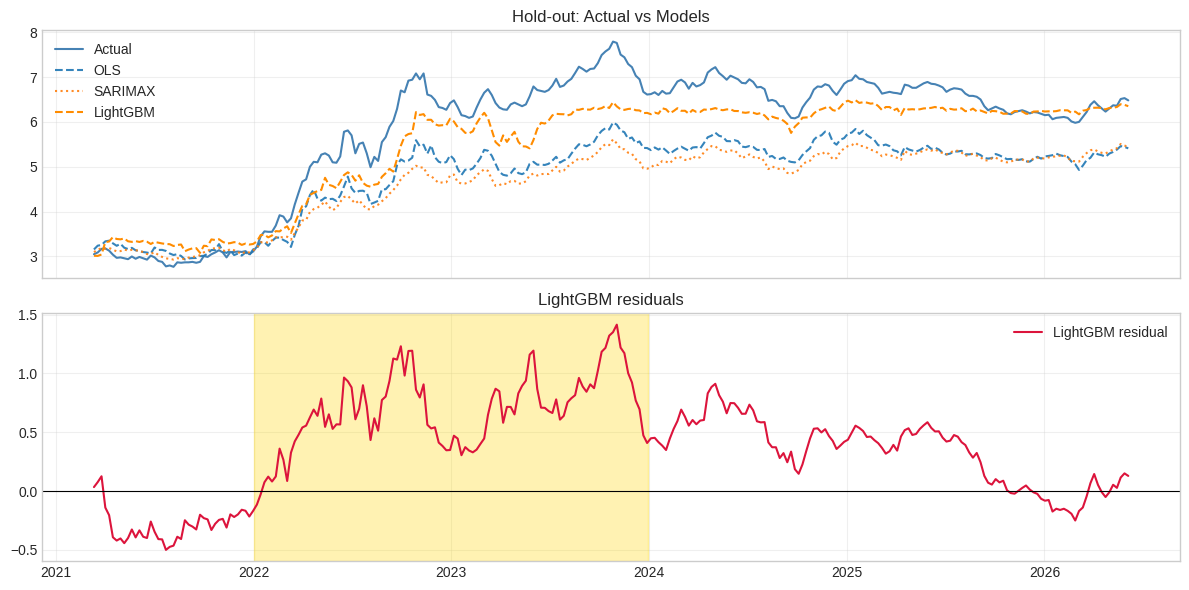

In [29]:
# Optional: actual vs predicted for classical best vs LightGBM
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(y_te.index, y_te, label='Actual', color='steelblue')
axes[0].plot(y_te.index, ols_pred, label='OLS', ls='--', alpha=0.9)
if sar_pred is not None:
    axes[0].plot(y_te.index, sar_pred, label='SARIMAX', ls=':', alpha=0.9)
axes[0].plot(y_te.index, lgb_pred, label='LightGBM', ls='--', color='darkorange')
axes[0].legend(); axes[0].set_title('Hold-out: Actual vs Models'); axes[0].grid(True, alpha=0.3)

axes[1].plot(y_te.index, y_te - lgb_pred, color='crimson', label='LightGBM residual')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.3)
axes[1].legend(); axes[1].set_title('LightGBM residuals'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

On a chronological hold-out, a one-week random walk achieves near-perfect short-horizon accuracy because mortgage rates are highly persistent. Conditional on exogenous macro features only (no lagged target), LightGBM substantially outperforms OLS and SARIMAX (test R² 0.84 vs 0.34 and 0.11) and reduces under-prediction during 2022–2023 relative to the classical models. The project’s claim is therefore about recoverable signal in Treasury and policy variables, not about replacing a random-walk benchmark for one-step-ahead point forecasts.

In [30]:
# Multi-step ahead: Random walk vs LightGBM (direct)
# Horizons: 4-week and 12-week

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

TARGET = 'MORTGAGE30US'
horizons = [4, 12]

data = feat[[TARGET] + features].dropna().copy()
split_idx = int(len(data) * 0.80)
train, test = data.iloc[:split_idx], data.iloc[split_idx:]

def eval_horizon(y_true, y_pred, name, h):
    # align: prediction made at t for y_{t+h}
    yt = y_true.copy()
    yp = y_pred.copy()
    mask = yt.notna() & yp.notna()
    yt, yp = yt[mask], yp[mask]
    resid = yt - yp
    row = {
        'Horizon': h,
        'Model': name,
        'N': int(mask.sum()),
        'MSE': round(mean_squared_error(yt, yp), 3),
        'R²': round(r2_score(yt, yp), 3),
        'Mean resid': round(resid.mean(), 3),
        'MAE': round(np.mean(np.abs(resid)), 3),
    }
    # stress window on the *target* dates
    stress = (yt.index >= '2022-01-01') & (yt.index <= '2023-12-31')
    if stress.sum() > 10:
        row['2022-23 mean resid'] = round(resid[stress].mean(), 3)
        row['2022-23 MSE'] = round(mean_squared_error(yt[stress], yp[stress]), 3)
    return row

rows = []

for h in horizons:
    # Random walk: ŷ_{t+h} = y_t
    # On test dates t, predict y_{t+h} using y_t
      full_y = data[TARGET]
    # predictions indexed by target date (t+h)
    rw_pred = full_y.shift(h)  # value at t predicts target at t+h → shift places y_t at index t+h
    # evaluate only on test target dates
    rw_te = rw_pred.reindex(test.index)
    rows.append(eval_horizon(test[TARGET], rw_te, 'Random walk', h))

    # Direct LightGBM: features at t → y_{t+h}
    # Build training labels shifted
    y_tr_h = train[TARGET].shift(-h)
    valid_tr = y_tr_h.notna()
    X_tr_h = train.loc[valid_tr, features]
    y_tr_h = y_tr_h.loc[valid_tr]

    model = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
    )
    model.fit(X_tr_h, y_tr_h)

    # Predict from each test row t for y_{t+h}; map to target date index
    pred_at_t = pd.Series(model.predict(test[features]), index=test.index)
    # target date = t + h weeks
    # Safer: use shift on a combined timeline
    combined_pred = pd.Series(index=data.index, dtype=float)
    # predictions only available for test origins
    for t in test.index:
        # find position of t and step h forward in data index
        loc = data.index.get_loc(t)
        if loc + h < len(data.index):
            target_date = data.index[loc + h]
            combined_pred.loc[target_date] = pred_at_t.loc[t]

    lgb_te = combined_pred.reindex(test.index)
    rows.append(eval_horizon(test[TARGET], lgb_te, 'LightGBM direct', h))

multi = pd.DataFrame(rows)
print(multi.to_string(index=False))

 Horizon           Model   N   MSE     R²  Mean resid   MAE  2022-23 mean resid  2022-23 MSE
       4     Random walk 274 0.089  0.957       0.052 0.222               0.143        0.179
       4 LightGBM direct 270 0.479  0.759       0.420 0.576               0.771        0.843
      12     Random walk 274 0.326  0.842       0.158 0.419               0.485        0.645
      12 LightGBM direct 262 2.283 -0.281       1.311 1.386               1.622        3.013


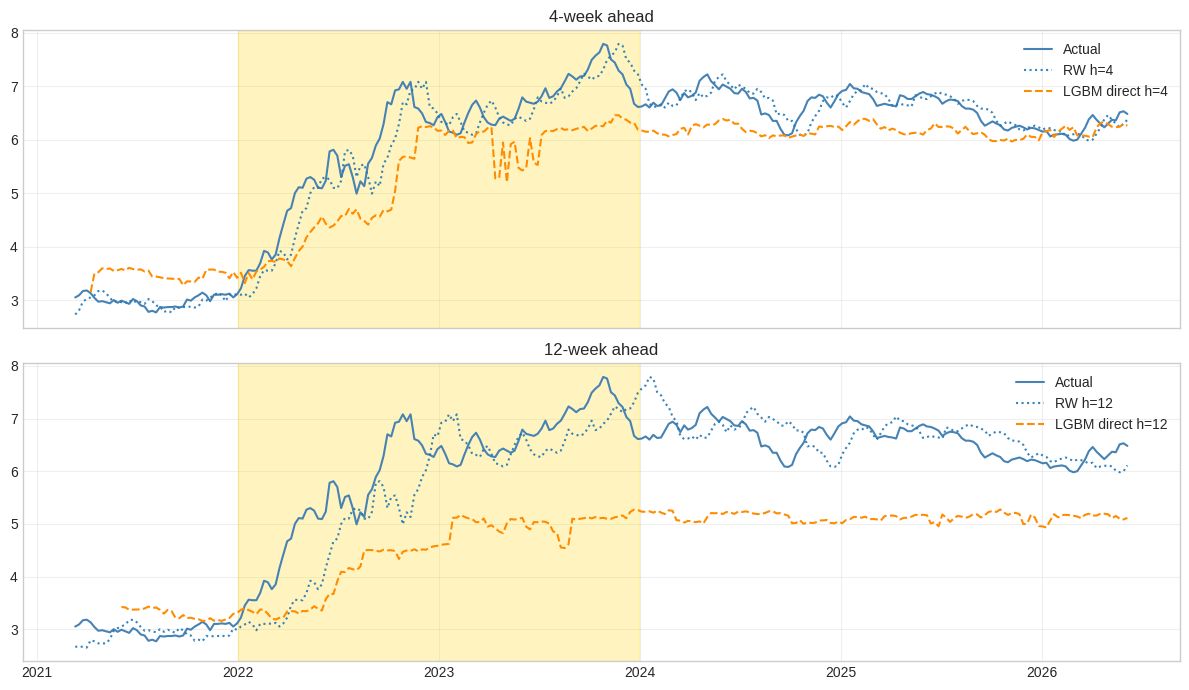

In [31]:
# LightGBM one-step rolled h times


import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(horizons), 1, figsize=(12, 3.5 * len(horizons)), sharex=True)
if len(horizons) == 1:
    axes = [axes]

for ax, h in zip(axes, horizons):
    sub = multi[multi['Horizon'] == h]

    full_y = data[TARGET]
    rw_plot = full_y.shift(h).reindex(test.index)

    y_tr_h = train[TARGET].shift(-h).dropna()
    X_tr_h = train.loc[y_tr_h.index, features]
    m = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
    )
    m.fit(X_tr_h, y_tr_h)
    pred_at_t = pd.Series(m.predict(test[features]), index=test.index)
    combined_pred = pd.Series(index=data.index, dtype=float)
    for t in test.index:
        loc = data.index.get_loc(t)
        if loc + h < len(data.index):
            combined_pred.loc[data.index[loc + h]] = pred_at_t.loc[t]
    lgb_plot = combined_pred.reindex(test.index)

    ax.plot(test.index, test[TARGET], label='Actual', color='steelblue')
    ax.plot(test.index, rw_plot, label=f'RW h={h}', ls=':', alpha=0.9)
    ax.plot(test.index, lgb_plot, label=f'LGBM direct h={h}', ls='--', color='darkorange')
    ax.axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.25)
    ax.set_title(f'{h}-week ahead'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Mortgage rates are highly persistent. A random-walk benchmark dominates pure multi-step point forecasts at 4- and 12-week horizons. The LightGBM model is evaluated as a structural / exogenous-information model: conditional on Treasury and policy features alone, it outperforms OLS and SARIMAX at the one-step horizon. Multi-step results show that this informational advantage does not automatically translate into beating persistence at longer horizons, especially through the 2022–2023 regime shift.

In [33]:
# Stacked indicators → mortgage rate CHANGE at h = 4, 8, 12
# Grid: stack recipe × horizon × model

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

TARGET = 'MORTGAGE30US'
horizons = [4, 8, 12]

data = feat.dropna().copy()
y = data[TARGET]

# Define stacks
def present(cols):
    return [c for c in cols if c in data.columns]

stack_A = present([  # Curve
    'DGS10', 'DGS10_lag1', 'DGS10_lag2', 'DGS10_lag4', 'DGS10_lag8', 'DGS10_lag12',
    'DGS10_roc1', 'DGS10_roc4', 'DGS10_roll4_mean', 'DGS10_roll12_mean',
    'YIELD_SPREAD', 'YIELD_SPREAD_lag1', 'YIELD_SPREAD_lag4', 'YIELD_SPREAD_lag12',
] + ([c for c in data.columns if c.startswith('DGS2')]))

stack_B = present([  # Policy
    'FEDFUNDS', 'FEDFUNDS_lag1', 'FEDFUNDS_lag4', 'FEDFUNDS_lag12',
    'FEDFUNDS_roc4', 'FEDFUNDS_change_12w', 'tightening_flag',
    'FEDFUNDS_roll4_mean', 'FEDFUNDS_roll12_mean',
])

stack_C = present([  # Vol / stress
    'DGS10_vol12', 'DGS10_roll4_std', 'DGS10_roll12_std',
    'FEDFUNDS_roll12_std', 'YIELD_SPREAD_roll12_std',
    'stress_prob', 'stress_label',
])

stack_D = present([  # Housing
    'HOUST', 'HOUST_lag1', 'HOUST_lag4', 'HOUST_lag12',
] + ([c for c in data.columns if c.startswith('PERMIT')]))

stack_E = present([  # Labor / prices
    'UNRATE', 'UNRATE_lag1', 'UNRATE_lag4', 'UNRATE_lag12',
    'CPIAUCSL', 'CPIAUCSL_lag1', 'CPIAUCSL_lag4',
])

stack_sets = {
    'A_curve': stack_A,
    'AB_curve_policy': stack_A + stack_B,
    'ABC_curve_policy_vol': stack_A + stack_B + stack_C,
    'full': stack_A + stack_B + stack_C + stack_D + stack_E,
}


def stack_scores(df, stacks_dict):
    out = pd.DataFrame(index=df.index)
    for name, cols in stacks_dict.items():
        cols = present(cols)
        if not cols:
            continue
        Z = StandardScaler().fit_transform(df[cols].fillna(df[cols].median()))
        out[f'score_{name}'] = Z.mean(axis=1)
    return out

base_stacks = {
    'A': stack_A, 'B': stack_B, 'C': stack_C, 'D': stack_D, 'E': stack_E
}
scores = stack_scores(data, base_stacks)
data = data.join(scores)
stack_sets['stack_scores_only'] = list(scores.columns)

#  Chronological split on origins
split_idx = int(len(data) * 0.80)
train_idx = data.index[:split_idx]
test_idx = data.index[split_idx:]

def fit_predict(model_name, X_tr, y_tr, X_te):
    if model_name == 'lgbm':
        m = lgb.LGBMRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
        )
        m.fit(X_tr, y_tr)
        return m.predict(X_te), m
    else:
        m = Ridge(alpha=1.0)
        m.fit(X_tr, y_tr)
        return m.predict(X_te), m

rows = []
for h in horizons:
    # Target: change from t to t+h
    delta = y.shift(-h) - y
    # Train rows: origin in train, label available
    tr_mask = data.index.isin(train_idx) & delta.notna()
    # Test: origin in test, label available
    te_mask = data.index.isin(test_idx) & delta.notna()

    y_tr = delta.loc[tr_mask]
    y_te = delta.loc[te_mask]
    # Stress: target week in 2022-23 (approx: origin + h in stress)
    # Use origin date in 2021-2023 for simplicity
    stress_te = (y_te.index >= '2021-06-01') & (y_te.index <= '2023-12-31')

    # Baseline: predict 0 change
    zero_pred = np.zeros(len(y_te))
    rows.append({
        'Horizon': h, 'Stack': 'zero_change', 'Model': 'baseline',
        'N_test': len(y_te),
        'R²': round(r2_score(y_te, zero_pred), 3),
        'MSE': round(mean_squared_error(y_te, zero_pred), 3),
        'MAE': round(mean_absolute_error(y_te, zero_pred), 3),
        'Mean resid': round((y_te - zero_pred).mean(), 3),
        '2022-23 MAE': round(mean_absolute_error(y_te[stress_te], zero_pred[stress_te]), 3) if stress_te.sum() > 5 else np.nan,
    })

    for stack_name, cols in stack_sets.items():
        cols = [c for c in cols if c in data.columns]
        if len(cols) < 2:
            continue
        X_tr = data.loc[tr_mask, cols]
        X_te = data.loc[te_mask, cols]
        for model_name in ['lgbm', 'ridge']:
            pred, _ = fit_predict(model_name, X_tr, y_tr, X_te)
            resid = y_te - pred
            rows.append({
                'Horizon': h, 'Stack': stack_name, 'Model': model_name,
                'N_test': len(y_te),
                'R²': round(r2_score(y_te, pred), 3),
                'MSE': round(mean_squared_error(y_te, pred), 3),
                'MAE': round(mean_absolute_error(y_te, pred), 3),
                'Mean resid': round(resid.mean(), 3),
                '2022-23 MAE': round(mean_absolute_error(y_te[stress_te], pred[stress_te]), 3) if stress_te.sum() > 5 else np.nan,
            })

grid = pd.DataFrame(rows)
print('Stack × Horizon grid (target = rate change)')
print(grid.sort_values(['Horizon', 'Model', 'R²'], ascending=[True, True, False]).to_string(index=False))

# Best per horizon
print('\nBest R² per horizon (excl. zero baseline)')
sub = grid[grid['Stack'] != 'zero_change']
print(sub.loc[sub.groupby('Horizon')['R²'].idxmax()][
    ['Horizon', 'Stack', 'Model', 'R²', 'MAE', '2022-23 MAE']
].to_string(index=False))

Stack × Horizon grid (target = rate change)
 Horizon                Stack    Model  N_test     R²   MSE   MAE  Mean resid  2022-23 MAE
       4          zero_change baseline     270 -0.028 0.089 0.221       0.050        0.292
       4              A_curve     lgbm     270  0.095 0.079 0.207       0.024        0.264
       4    stack_scores_only     lgbm     270 -0.056 0.092 0.228       0.074        0.296
       4                 full     lgbm     270 -0.075 0.094 0.225       0.054        0.290
       4 ABC_curve_policy_vol     lgbm     270 -0.092 0.095 0.227       0.006        0.291
       4      AB_curve_policy     lgbm     270 -0.104 0.096 0.230      -0.001        0.285
       4      AB_curve_policy    ridge     270  0.170 0.072 0.196       0.043        0.257
       4 ABC_curve_policy_vol    ridge     270  0.168 0.072 0.197       0.042        0.258
       4              A_curve    ridge     270  0.161 0.073 0.196       0.048        0.257
       4                 full    ridge     270

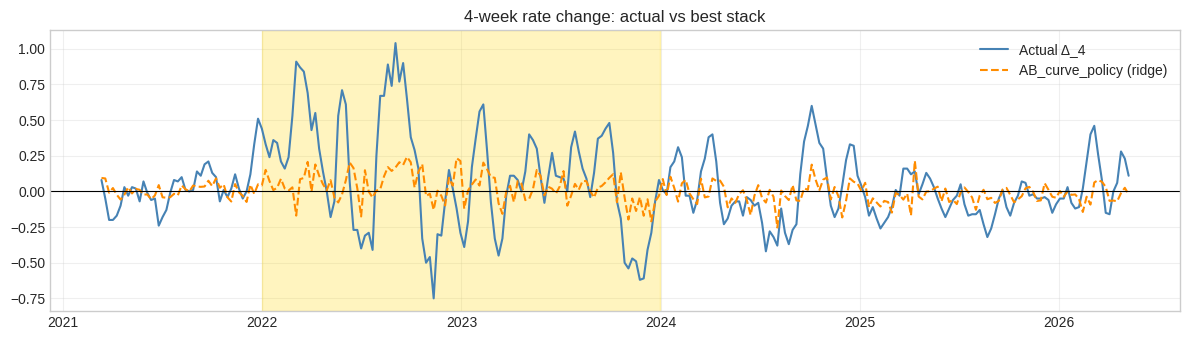

In [34]:
# plot best stack at h=4 vs actual change
import matplotlib.pyplot as plt

h = 4
delta = y.shift(-h) - y
te_mask = data.index.isin(test_idx) & delta.notna()
y_te = delta.loc[te_mask]
best = sub[sub['Horizon'] == h].sort_values('R²', ascending=False).iloc[0]
cols = stack_sets[best['Stack']]
cols = [c for c in cols if c in data.columns]
tr_mask = data.index.isin(train_idx) & delta.notna()
pred, _ = fit_predict(best['Model'], data.loc[tr_mask, cols], delta.loc[tr_mask], data.loc[te_mask, cols])

plt.figure(figsize=(12, 3.5))
plt.plot(y_te.index, y_te, label=f'Actual Δ_{h}', color='steelblue')
plt.plot(y_te.index, pred, label=f"{best['Stack']} ({best['Model']})", ls='--', color='darkorange')
plt.axhline(0, color='k', lw=0.8)
plt.axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.25)
plt.title(f'{h}-week rate change: actual vs best stack')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

When the target is the multi-week change in mortgage rates, a simple Ridge model on curve and policy indicators achieves modest skill at a 4-week horizon (R² ≈ 0.17 vs a no-change baseline) that fades by 12 weeks; richer stacks and tree models do not improve out-of-sample performance.

LightGBM expanding-fold tune (top 5)
 learning_rate  max_depth  num_leaves  mean_val_R2  std_val_R2
         0.030          4          15       -2.045       2.367
         0.030          4          31       -2.046       2.367
         0.080          4          15       -2.140       2.560
         0.080          4          31       -2.143       2.557
         0.050          4          15       -2.230       2.551
Locked params: {'learning_rate': 0.03, 'max_depth': 4, 'num_leaves': 15}

=== Lasso: non-zero coefficients ===
CPIAUCSL_lag1             -0.089
CPIAUCSL                  -0.044
FEDFUNDS_change_12w       -0.023
DGS10_roll4_std            0.008
DGS10_vol12                0.010
YIELD_SPREAD_roll12_std    0.019
DGS10_roll12_std           0.027
DGS10_lag2                 0.040
FEDFUNDS_roll12_std        0.045
DGS10_lag12                0.049
DGS10                      0.068
DGS10_roll12_mean          0.118
FEDFUNDS_lag12             0.129
DGS10_roll4_mean           0.165
DGS10_lag1  

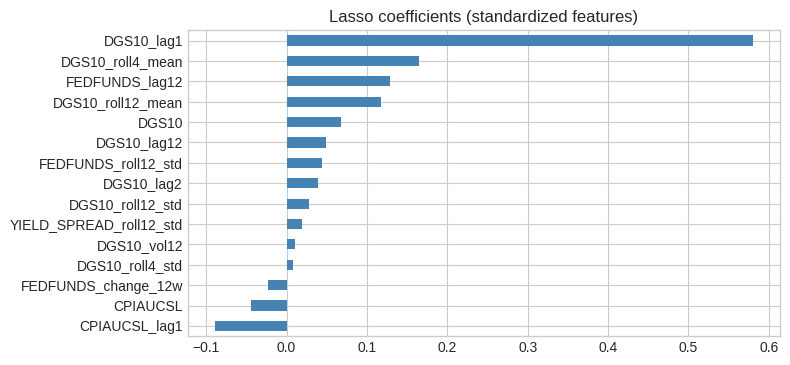


Bootstrap 90% band coverage: overall=0.047 | 2022-23=0.000


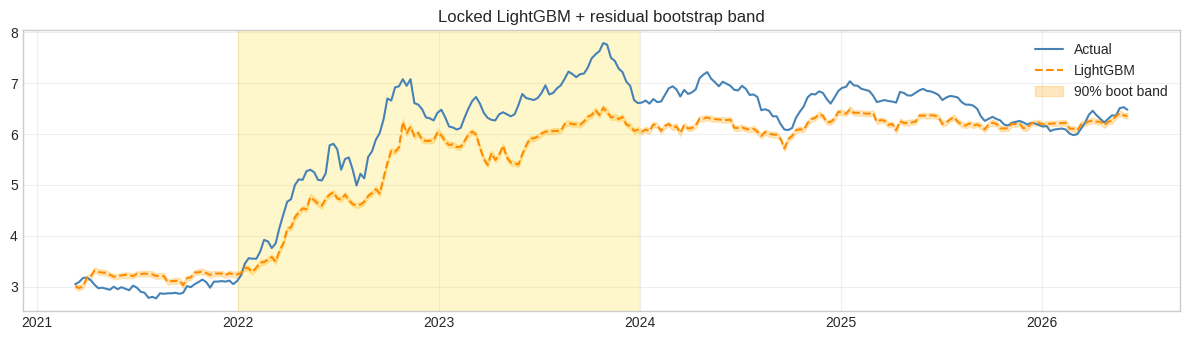


PCA variance explained (cumsum): [0.396 0.582 0.683 0.745 0.796 0.83  0.86  0.882 0.901 0.918]

Final comparison
               Model  Test MSE  Test R²  Mean resid  2022-23 mean resid  2022-23 MSE
                 OLS     1.353    0.344       1.011               1.241        1.728
             LassoCV     1.194    0.421       0.932               1.197        1.611
LightGBM (CV-locked)     0.343    0.833       0.417               0.727        0.617
        Ridge on PCA     1.511    0.267       1.073               1.306        1.907
     LightGBM on PCA     0.806    0.609       0.575               0.915        1.252


In [35]:
# ISL-style next steps
# 1) Expanding-fold tune LightGBM → lock → final test
# 2) Lasso path + coef plot + vs OLS / LightGBM
# 3) Residual bootstrap prediction bands
# 4) PCA features → Ridge / LightGBM

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import LinearRegression, LassoCV, Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

TARGET = 'MORTGAGE30US'
data = feat[[TARGET] + features].dropna().copy()
split_idx = int(len(data) * 0.80)
train, test = data.iloc[:split_idx], data.iloc[split_idx:]
X_tr, y_tr = train[features], train[TARGET]
X_te, y_te = test[features], test[TARGET]
mask_tt = (test.index >= '2022-01-01') & (test.index <= '2023-12-31')

def report(name, y_true, y_pred):
    resid = y_true - y_pred
    row = {
        'Model': name,
        'Test MSE': round(mean_squared_error(y_true, y_pred), 3),
        'Test R²': round(r2_score(y_true, y_pred), 3),
        'Mean resid': round(resid.mean(), 3),
    }
    if mask_tt.sum() > 0:
        row['2022-23 mean resid'] = round(resid[mask_tt].mean(), 3)
        row['2022-23 MSE'] = round(mean_squared_error(y_true[mask_tt], y_pred[mask_tt]), 3)
    return row


# 1) Expanding-fold tune LightGBM (train only), then final test

def expanding_folds(n, n_folds=5, min_train=0.40):
    """Yield (train_slice, val_slice) as integer positions on training array."""
    start = int(n * min_train)
    val_sizes = np.linspace(start, n, n_folds + 1, dtype=int)[1:]
    prev = start
    for end in val_sizes:
        tr = np.arange(0, prev)
        va = np.arange(prev, end)
        if len(va) < 20 or len(tr) < 50:
            prev = end
            continue
        yield tr, va
        prev = end

param_grid = {
    'learning_rate': [0.03, 0.05, 0.08],
    'max_depth': [4, 6, 8],
    'num_leaves': [15, 31],
}
grid = list(ParameterGrid(param_grid))
tune_rows = []

for p in grid:
    val_scores = []
    for tr_ix, va_ix in expanding_folds(len(X_tr), n_folds=5):
        m = lgb.LGBMRegressor(
            n_estimators=400, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=-1, **p
        )
        m.fit(X_tr.iloc[tr_ix], y_tr.iloc[tr_ix])
        pred = m.predict(X_tr.iloc[va_ix])
        val_scores.append(r2_score(y_tr.iloc[va_ix], pred))
    tune_rows.append({**p, 'mean_val_R2': np.mean(val_scores), 'std_val_R2': np.std(val_scores)})

tune_df = pd.DataFrame(tune_rows).sort_values('mean_val_R2', ascending=False)
print('LightGBM expanding-fold tune (top 5)')
print(tune_df.head().to_string(index=False))

best_p = tune_df.iloc[0][['learning_rate', 'max_depth', 'num_leaves']].to_dict()
best_p = {k: (int(v) if k != 'learning_rate' else float(v)) for k, v in best_p.items()}
print('Locked params:', best_p)

lgbm_locked = lgb.LGBMRegressor(
    n_estimators=500, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=-1, **best_p
)
lgbm_locked.fit(X_tr, y_tr)
lgb_pred = pd.Series(lgbm_locked.predict(X_te), index=test.index)


# 2) Lasso path

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

lasso = LassoCV(cv=5, max_iter=5000, random_state=42, n_alphas=60)
# Use expanding-style by plain CV on train only
lasso.fit(X_tr_s, y_tr)
lasso_pred = pd.Series(lasso.predict(X_te_s), index=test.index)

coef = pd.Series(lasso.coef_, index=features)
coef_nz = coef[coef != 0].sort_values()
print('\n=== Lasso: non-zero coefficients ===')
print(coef_nz.to_string())
print('alpha_:', round(lasso.alpha_, 5), '| n non-zero:', (coef != 0).sum())

plt.figure(figsize=(8, max(3, 0.25 * len(coef_nz))))
coef_nz.plot(kind='barh', color='steelblue')
plt.title('Lasso coefficients (standardized features)')
plt.tight_layout(); plt.show()

ols = LinearRegression().fit(X_tr_s, y_tr)
ols_pred = pd.Series(ols.predict(X_te_s), index=test.index)


# 3) Residual bootstrap bands on locked LightGBM

resid_tr = y_tr - lgbm_locked.predict(X_tr)
rng = np.random.default_rng(42)
B = 300
boot = np.column_stack([
    lgb_pred.values + rng.choice(resid_tr.values, size=len(lgb_pred), replace=True)
    for _ in range(B)
])
band_lo = pd.Series(np.quantile(boot, 0.05, axis=1), index=test.index)
band_hi = pd.Series(np.quantile(boot, 0.95, axis=1), index=test.index)
cover = ((y_te >= band_lo) & (y_te <= band_hi)).mean()
cover_tt = ((y_te[mask_tt] >= band_lo[mask_tt]) & (y_te[mask_tt] <= band_hi[mask_tt])).mean() if mask_tt.sum() else np.nan
print(f'\nBootstrap 90% band coverage: overall={cover:.3f} | 2022-23={cover_tt:.3f}')

plt.figure(figsize=(12, 3.5))
plt.plot(y_te.index, y_te, label='Actual', color='steelblue')
plt.plot(y_te.index, lgb_pred, label='LightGBM', ls='--', color='darkorange')
plt.fill_between(y_te.index, band_lo, band_hi, color='orange', alpha=0.25, label='90% boot band')
plt.axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.2)
plt.legend(); plt.title('Locked LightGBM + residual bootstrap band'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# 4) PCA on exogenous → Ridge / LightGBM

pca = PCA(n_components=min(15, X_tr_s.shape[1]), random_state=42)
Z_tr = pca.fit_transform(X_tr_s)
Z_te = pca.transform(X_te_s)
print('\nPCA variance explained (cumsum):', np.round(np.cumsum(pca.explained_variance_ratio_), 3)[:10])

ridge_pca = Ridge(alpha=1.0).fit(Z_tr, y_tr)
lgb_pca = lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
).fit(Z_tr, y_tr)

ridge_pca_pred = pd.Series(ridge_pca.predict(Z_te), index=test.index)
lgb_pca_pred = pd.Series(lgb_pca.predict(Z_te), index=test.index)


# Summary table

summary = pd.DataFrame([
    report('OLS', y_te, ols_pred),
    report('LassoCV', y_te, lasso_pred),
    report('LightGBM (CV-locked)', y_te, lgb_pred),
    report('Ridge on PCA', y_te, ridge_pca_pred),
    report('LightGBM on PCA', y_te, lgb_pca_pred),
])
print('\nFinal comparison')
print(summary.to_string(index=False))

The preprocessing and feature-engineering phase was used not only to build an exogenous weekly feature matrix but to stress-test it against the main failure modes emphasized in the rate-forecast literature: target leakage, structural breaks, and regime-dependent mortgage–Treasury spreads. Ablation established that target-derived lags inflate hold-out fit from about 0.84 to 0.98 and were removed. Lagged cross-correlations and spread diagnostics aligned feature choices with Treasury and policy drivers and with the 2022–2023 widening of the mortgage–Treasury spread. Multi-origin evaluation, multi-step benchmarks, stacked change-models, regularized sparse linear alternatives, and residual bootstrap intervals further documented that skill is real on an exogenous information set, concentrated at short horizons, and systematically stressed in rapid tightening regimes—consistent with the break and regime themes in the cited macro-finance work.

In [36]:
# Report figures — Preprocessing & Feature Engineering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TARGET = 'MORTGAGE30US'


def save_show(name):
    plt.tight_layout()
    plt.savefig(f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {name}.png')

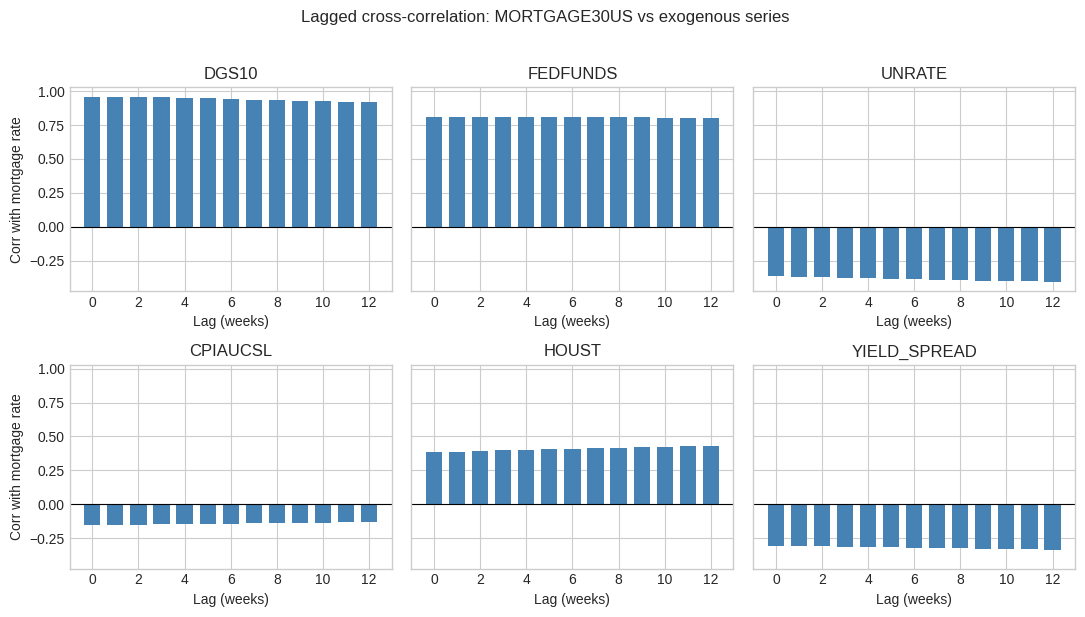

Saved fig1_lagged_crosscorr.png


In [37]:
series_list = [c for c in ['DGS10', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'HOUST', 'YIELD_SPREAD'] if c in feat.columns]
max_lag = 12
rows = []
for c in series_list:
    for k in range(0, max_lag + 1):
        rows.append({'series': c, 'lag': k, 'corr': feat[TARGET].corr(feat[c].shift(k))})
cc = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharey=True)
axes = axes.ravel()
for i, c in enumerate(series_list):
    sub = cc[cc['series'] == c]
    axes[i].bar(sub['lag'], sub['corr'], color='steelblue', width=0.7)
    axes[i].axhline(0, color='k', lw=0.8)
    axes[i].set_title(c)
    axes[i].set_xlabel('Lag (weeks)')
    if i % 3 == 0:
        axes[i].set_ylabel('Corr with mortgage rate')
for j in range(len(series_list), len(axes)):
    axes[j].axis('off')
fig.suptitle('Lagged cross-correlation: MORTGAGE30US vs exogenous series', y=1.02)
save_show('fig1_lagged_crosscorr')

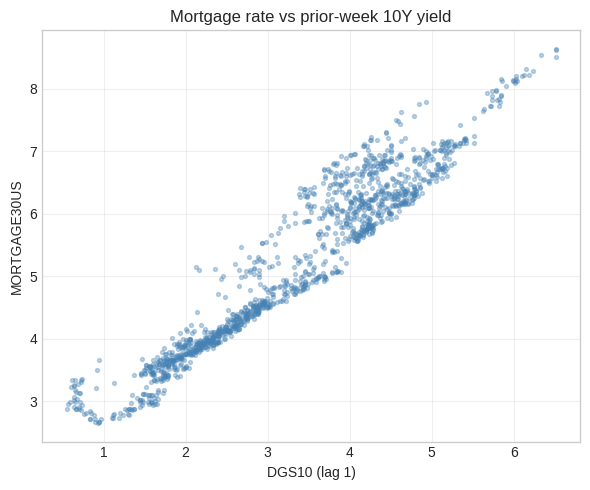

Saved fig2_scatter_dgs10_lag1.png


In [38]:
if 'DGS10' in feat.columns:
    x = feat['DGS10'].shift(1)
    y = feat[TARGET]
    m = x.notna() & y.notna()
    plt.figure(figsize=(6, 5))
    plt.scatter(x[m], y[m], s=8, alpha=0.35, color='steelblue')
    plt.xlabel('DGS10 (lag 1)')
    plt.ylabel('MORTGAGE30US')
    plt.title('Mortgage rate vs prior-week 10Y yield')
    plt.grid(True, alpha=0.3)
    save_show('fig2_scatter_dgs10_lag1')

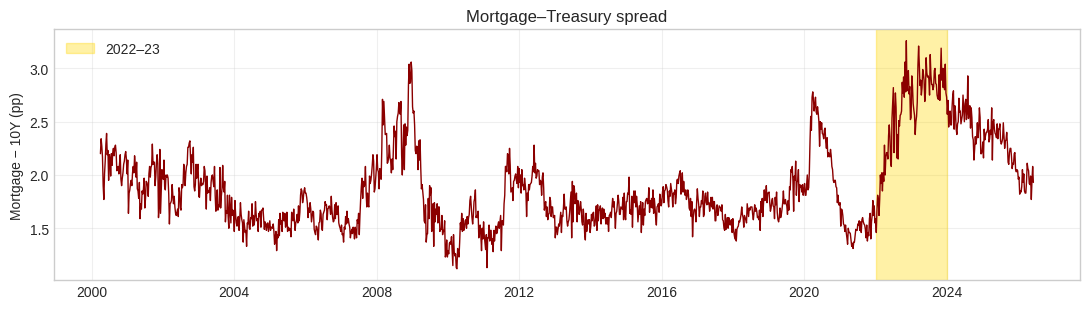

Saved fig3_mortgage_treasury_spread.png


In [39]:
spread = feat[TARGET] - feat['DGS10']
plt.figure(figsize=(11, 3.2))
plt.plot(spread.index, spread, color='darkred', lw=1)
plt.axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.35, label='2022–23')
plt.ylabel('Mortgage − 10Y (pp)')
plt.title('Mortgage–Treasury spread')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
save_show('fig3_mortgage_treasury_spread')

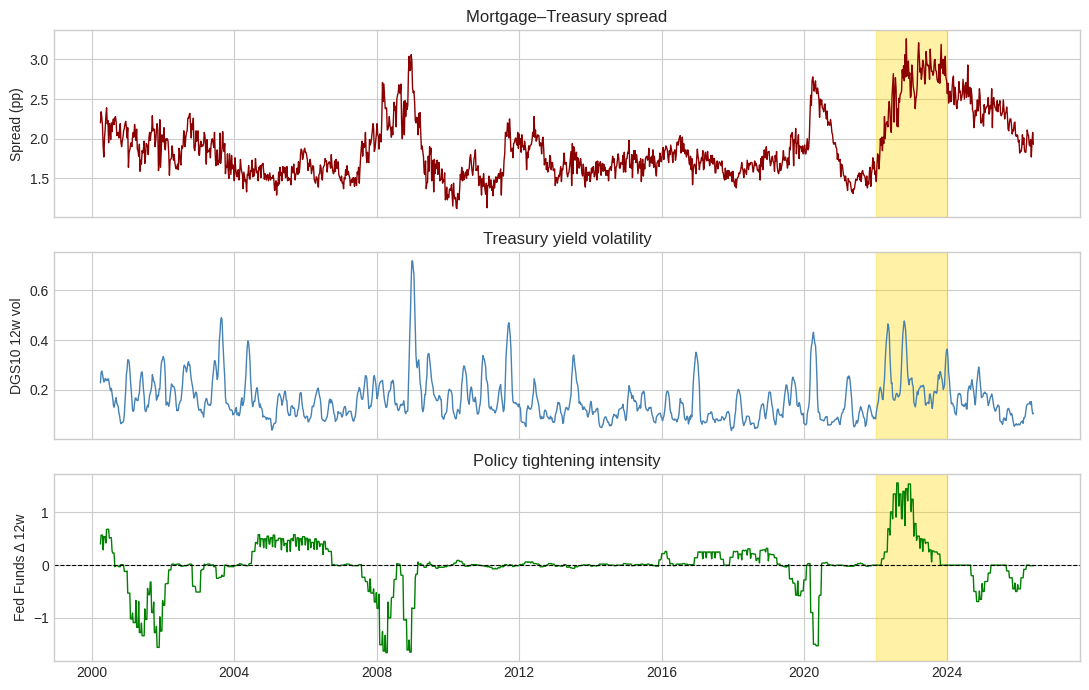

Saved fig4_spread_vol_policy.png


In [40]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(spread.index, spread, color='darkred', lw=1)
axes[0].axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.35)
axes[0].set_ylabel('Spread (pp)')
axes[0].set_title('Mortgage–Treasury spread')

if 'DGS10_vol12' in feat.columns:
    axes[1].plot(feat.index, feat['DGS10_vol12'], color='steelblue', lw=1)
    axes[1].axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.35)
    axes[1].set_ylabel('DGS10 12w vol')
    axes[1].set_title('Treasury yield volatility')

if 'FEDFUNDS_change_12w' in feat.columns:
    axes[2].plot(feat.index, feat['FEDFUNDS_change_12w'], color='green', lw=1)
    axes[2].axhline(0, color='k', ls='--', lw=0.8)
    axes[2].axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.35)
    axes[2].set_ylabel('Fed Funds Δ 12w')
    axes[2].set_title('Policy tightening intensity')

save_show('fig4_spread_vol_policy')

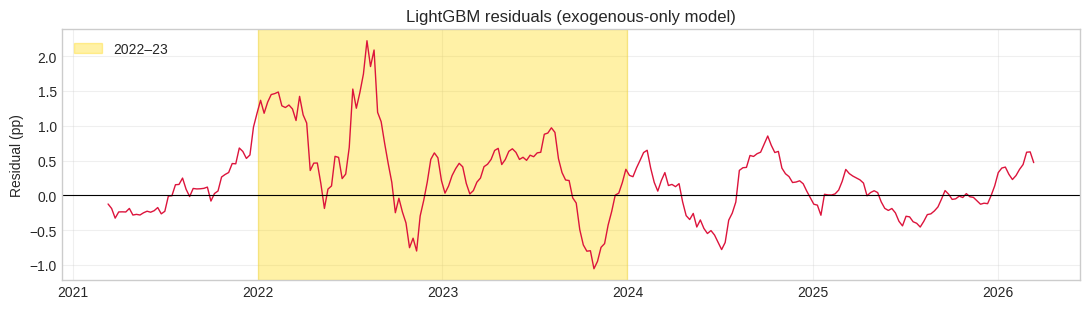

Saved fig5_residuals.png


In [41]:


plt.figure(figsize=(11, 3.2))
plt.plot(resid.index, resid, color='crimson', lw=1)
plt.axhline(0, color='k', lw=0.8)
plt.axvspan('2022-01-01', '2023-12-31', color='gold', alpha=0.35, label='2022–23')
plt.ylabel('Residual (pp)')
plt.title('LightGBM residuals (exogenous-only model)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
save_show('fig5_residuals')

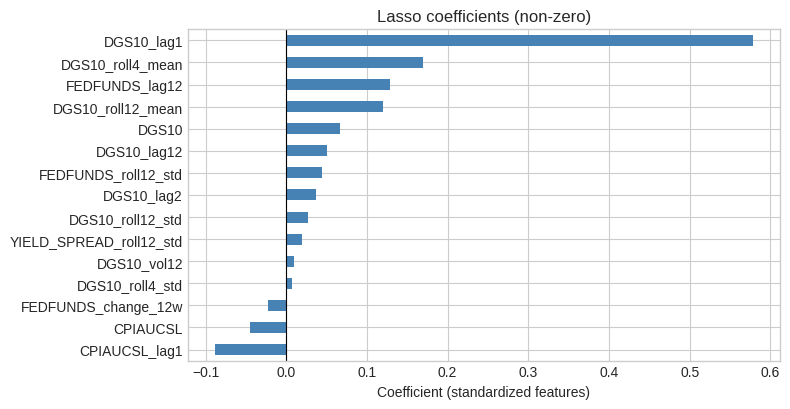

Saved fig6_lasso_coefs.png


In [42]:

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

X = feat[features].dropna()
y = feat.loc[X.index, TARGET]
split = int(len(X) * 0.80)
scaler = StandardScaler()
Xs = scaler.fit_transform(X.iloc[:split])
lasso = LassoCV(cv=5, max_iter=5000, random_state=42).fit(Xs, y.iloc[:split])
coef = pd.Series(lasso.coef_, index=features)
coef_nz = coef[coef != 0].sort_values()

plt.figure(figsize=(8, max(3.5, 0.28 * len(coef_nz))))
coef_nz.plot(kind='barh', color='steelblue')
plt.xlabel('Coefficient (standardized features)')
plt.title('Lasso coefficients (non-zero)')
plt.axvline(0, color='k', lw=0.8)
save_show('fig6_lasso_coefs')

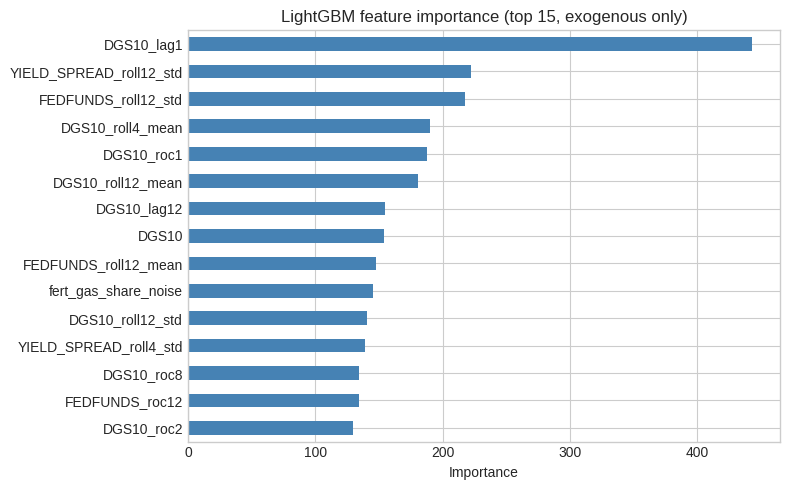

Saved fig7_lgbm_importance.png


In [43]:
imp_top = imp.sort_values(ascending=True).tail(15)
plt.figure(figsize=(8, 5))
imp_top.plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('LightGBM feature importance (top 15, exogenous only)')
save_show('fig7_lgbm_importance')

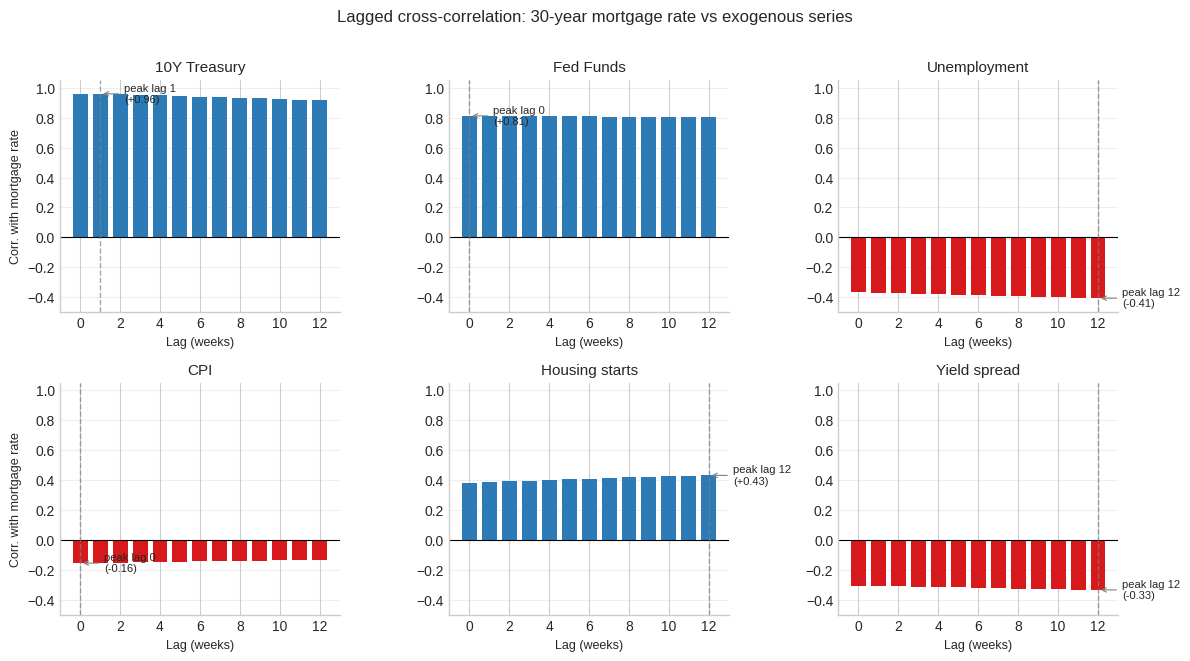

In [44]:
# Improved lagged cross-correlation figure
series_list = [c for c in ['DGS10', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'HOUST', 'YIELD_SPREAD'] if c in feat.columns]
max_lag = 12
titles = {
    'DGS10': '10Y Treasury',
    'FEDFUNDS': 'Fed Funds',
    'UNRATE': 'Unemployment',
    'CPIAUCSL': 'CPI',
    'HOUST': 'Housing starts',
    'YIELD_SPREAD': 'Yield spread',
}

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
axes = axes.ravel()

for i, c in enumerate(series_list):
    corrs = [feat[TARGET].corr(feat[c].shift(k)) for k in range(0, max_lag + 1)]
    lags = list(range(0, max_lag + 1))
    colors = ['#2c7bb6' if v >= 0 else '#d7191c' for v in corrs]
    axes[i].bar(lags, corrs, color=colors, width=0.75, edgecolor='none')
    axes[i].axhline(0, color='black', lw=0.8)

    # mark peak
    peak = int(np.nanargmax(np.abs(corrs)))
    axes[i].axvline(peak, color='gray', ls='--', lw=1, alpha=0.7)
    axes[i].annotate(
        f'peak lag {peak}\n({corrs[peak]:+.2f})',
        xy=(peak, corrs[peak]),
        xytext=(peak + 1.2, corrs[peak]),
        fontsize=8,
        va='center',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
    )

    axes[i].set_title(titles.get(c, c), fontsize=11)
    axes[i].set_xlabel('Lag (weeks)', fontsize=9)
    if i % 3 == 0:
        axes[i].set_ylabel('Corr. with mortgage rate', fontsize=9)
    axes[i].set_xticks(range(0, max_lag + 1, 2))
    axes[i].set_ylim(-0.5, 1.05)
    axes[i].grid(True, axis='y', alpha=0.3)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

for j in range(len(series_list), len(axes)):
    axes[j].axis('off')

fig.suptitle(
    'Lagged cross-correlation: 30-year mortgage rate vs exogenous series',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('fig1_lagged_crosscorr.png', dpi=150, bbox_inches='tight')
plt.show()